In [8]:
import torch
from datasets import load_dataset
from transformers import pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipeline("automatic-speech-recognition", model="openai/whisper-tiny", device=device)

dataset = load_dataset("distil-whisper/librispeech_long", "clean", split="validation")
sample = dataset[0]["audio"]

print(f"Sample keys immediately after load: {sample.keys()}")
print(f"Sample array shape: {sample['array'].shape if 'array' in sample else 'Missing'}")

# Long audio requires return_timestamps=True
result = pipe(sample, return_timestamps=True)
print(result["text"])

Device set to use cuda


Sample keys immediately after load: dict_keys(['path', 'array', 'sampling_rate'])
Sample array shape: (999280,)


c:\Users\danny\anaconda3\envs\py310\lib\site-packages\transformers\models\whisper\generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Whisper did not predict an ending timestamp, which can happen if audio is cut off in the middle of a word. Also make sure WhisperTimeStampLogitsProcessor was used during generation.


 Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel. Nor is Mr. Quilter's manner less interesting than his matter. He tells us that at this festive season of the year, with Christmas and roast beef looming before us, similarly drawn from eating and its results occur most readily to the mind. He has grave doubts whether Sir Frederick Latins' work is really Greek after all, and can discover in it but little of rocky ithaka. Lennils, pictures, are a sort of upguards and atom paintings, and Mason's exquisite itals are as national as a jingo poem. Mr. Birkut Foster's landscapes smile at one much in the same way that Mr. Carker used to flash his teeth. And Mr. John Collier gives his sitter a cheerful slap on the back before he says, like a shampoo and a Turkish bath next man.


In [9]:
print(result["text"])

 Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel. Nor is Mr. Quilter's manner less interesting than his matter. He tells us that at this festive season of the year, with Christmas and roast beef looming before us, similarly drawn from eating and its results occur most readily to the mind. He has grave doubts whether Sir Frederick Latins' work is really Greek after all, and can discover in it but little of rocky ithaka. Lennils, pictures, are a sort of upguards and atom paintings, and Mason's exquisite itals are as national as a jingo poem. Mr. Birkut Foster's landscapes smile at one much in the same way that Mr. Carker used to flash his teeth. And Mr. John Collier gives his sitter a cheerful slap on the back before he says, like a shampoo and a Turkish bath next man.


In [28]:

# --- 3. Robust Adversarial Attack Loop ---
def apply_robustness_transforms(waveform, noise_level=0.01):
    """Applies differentiable transformations to simulate RIR and Noise"""
    device = waveform.device
    
    # 1. Add Gaussian Noise (Static)
    if torch.rand(1) > 0.3:
        # Random noise level
        nl = noise_level * torch.rand(1).to(device)
        waveform = waveform + torch.randn_like(waveform) * nl

    # 2. Amplitude Scaling (Simulation of different recording volumes)
    if torch.rand(1) > 0.3:
        scale = 0.9 + 0.2 * torch.rand(1).to(device) 
        waveform = waveform * scale

    # 3. Simple Echo/Reverb simulation (Approximation of RIR)
    # We add a decayed version of the signal delayed by random amount
    if torch.rand(1) > 0.5:
        # Delay between 50ms (800 samples) and 200ms (3200 samples)
        delay = int(torch.randint(800, 3000, (1,)).item())
        decay = 0.4 * torch.rand(1).to(device) # Random decay
        
        # Create delayed signal
        delayed = torch.zeros_like(waveform)
        if delay < waveform.shape[-1]:
            delayed[..., delay:] = waveform[..., :-delay]
            
        waveform = waveform + decay * delayed
        # Normalize roughly
        waveform = waveform / (1.0 + decay)
        
    return waveform

def run_adversarial_attack(initial_audio, target_text, model, processor, diff_fe, steps=100, lr=0.01, noise_limit=0.04, l2_penalty=0.0, robust=False):
    adv_audio = initial_audio.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([adv_audio], lr=lr)
    
    target_ids = processor.tokenizer(target_text, return_tensors="pt").input_ids.to(device)
    target_tensor = target_ids
    
    print(f"Optimizing for target: '{target_text}' over {steps} steps (Robust: {robust})...")
    
    for i in range(steps):
        optimizer.zero_grad()
        
        with torch.no_grad():
            delta = adv_audio - initial_audio
            delta = torch.clamp(delta, -noise_limit, noise_limit)
            adv_audio.data = initial_audio + delta

        # Expectation over Transforms (EoT) if robust
        # We run the forward pass on a transformed version, but gradients flow back to adv_audio
        if robust:
            input_audio_transformed = apply_robustness_transforms(adv_audio, noise_level=0.01)
        else:
            input_audio_transformed = adv_audio

        # Forward pass
        input_features = diff_fe(input_audio_transformed)
        input_features_model = input_features.to(model.dtype)
        
        outputs = model(input_features=input_features_model, labels=target_tensor)
        ce_loss = outputs.loss
        
        # Add L2 penalty 
        diff = adv_audio - initial_audio
        l2_loss = torch.norm(diff, p=2)
        
        loss = ce_loss + l2_penalty * l2_loss
        
        loss.backward()
        optimizer.step()
        
        if i % 100 == 0:
            print(f"Step {i}, CE Loss: {ce_loss.item():.4f}, L2: {l2_loss.item():.2f}")
            
    return adv_audio.detach()

# --- 4. Prepare Data Helper ---
# ... (get_audio_array function, dataset loading, and truncation from previous cells remains implicit or we re-run)
# Reuse existing variables if possible, but let's redefine to be safe
def get_audio_array(sample):
    if 'array' in sample:
        return sample['array']
    elif 'audio' in sample and 'array' in sample['audio']:
        return sample['audio']['array']
    else:
        if 'path' in sample:
             y, _ = librosa.load(sample['path'], sr=16000)
             return y
        elif 'audio' in sample and 'path' in sample['audio']:
             y, _ = librosa.load(sample['audio']['path'], sr=16000)
             return y
        raise ValueError("Could not find audio array in sample")

dataset = load_dataset("distil-whisper/librispeech_long", "clean", split="validation")
sample = dataset[0]
audio_array = get_audio_array(sample)
max_samples = 16000 * 2
if len(audio_array) > max_samples:
    audio_array = audio_array[:max_samples]
original_waveform = torch.tensor(audio_array, device=device).float().unsqueeze(0)
target_text = "Hello world"


print("\n--- Generating Robust Speech-like Adversarial Example ---")
# Robust attack needs more steps and maybe higher noise allowance to fight through RIR
adv_speech = run_adversarial_attack(
    original_waveform, 
    target_text, 
    model, 
    processor, 
    diff_fe, 
    steps=1500,       
    lr=0.001,         
    noise_limit=0.005, # Higher limit for robustness
    l2_penalty=0.01,
    robust=True
)

print("\n--- Generating Robust Noise-like Adversarial Example ---")
noise_waveform = torch.randn_like(original_waveform) * 0.05
noise_waveform.requires_grad_(True)

adv_noise = run_adversarial_attack(
    noise_waveform, 
    target_text, 
    model, 
    processor, 
    diff_fe, 
    steps=1000, 
    lr=0.005, 
    noise_limit=0.1, # Robust noise needs to be louder
    l2_penalty=0.05,
    robust=True
)

# Save results
sf.write("adv_speech.wav", adv_speech.cpu().numpy().flatten(), 16000)
sf.write("adv_noise.wav", adv_noise.cpu().numpy().flatten(), 16000)

# --- Robustness Evaluation Header --
print("\n=== Robustness Evaluation ===")
def test_transcription(waveform, description):
    with torch.no_grad():
        forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
        feats = diff_fe(waveform).to(model.dtype)
        generated_ids = model.generate(feats, forced_decoder_ids=forced_ids)
        transcription = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(f"[{description}] -> '{transcription}'")

# Test clean
test_transcription(adv_noise, "Clean Noise-like")
# Test with interference
# 1. Static
noisy = adv_noise + torch.randn_like(adv_noise) * 0.02
test_transcription(noisy, "With Static Noise (0.02)")
# 2. Reverb
reverbed = apply_robustness_transforms(adv_noise, noise_level=0.0) # Just reverb/scale
test_transcription(reverbed, "With Random Reverb/Scale")


--- Generating Robust Speech-like Adversarial Example ---
Optimizing for target: 'Hello world' over 1500 steps (Robust: True)...
Step 0, CE Loss: 8.7266, L2: 0.00
Step 100, CE Loss: 5.3516, L2: 0.72
Step 200, CE Loss: 4.6172, L2: 0.73
Step 300, CE Loss: 5.4414, L2: 0.73
Step 400, CE Loss: 5.0781, L2: 0.74
Step 500, CE Loss: 6.0234, L2: 0.71
Step 600, CE Loss: 5.3789, L2: 0.73
Step 700, CE Loss: 5.8789, L2: 0.73
Step 800, CE Loss: 6.7617, L2: 0.71
Step 900, CE Loss: 6.3750, L2: 0.72
Step 1000, CE Loss: 6.5273, L2: 0.72
Step 1100, CE Loss: 4.4727, L2: 0.72
Step 1200, CE Loss: 5.7383, L2: 0.72
Step 1300, CE Loss: 7.3477, L2: 0.73
Step 1400, CE Loss: 7.0156, L2: 0.71

--- Generating Robust Noise-like Adversarial Example ---
Optimizing for target: 'Hello world' over 1000 steps (Robust: True)...
Step 0, CE Loss: 9.7422, L2: 0.00
Step 100, CE Loss: 1.3652, L2: 7.81
Step 200, CE Loss: 0.7202, L2: 9.69
Step 300, CE Loss: 0.6802, L2: 10.01
Step 400, CE Loss: 0.1711, L2: 9.77
Step 500, CE Loss: 

In [15]:
print(dataset)
print(dataset.column_names)
print(dataset[0])

Dataset({
    features: ['audio'],
    num_rows: 1
})
['audio']
{'audio': {'path': '0d38672e0bbdbdc460af55b8bb84a15b2730db2819f2af64f9c777d4d586f2de', 'array': array([0.00238037, 0.0020752 , 0.00198364, ..., 0.00024414, 0.00048828,
       0.0005188 ]), 'sampling_rate': 16000}}


In [16]:
import numpy
print(numpy.__version__)

1.25.2


In [27]:
from IPython.display import Audio, display
import numpy as np
import librosa
import torch

print("--- Original Audio ---")
# dataset loaded in previous cells doesn't have text label, so let's transcribe it
# We need to make sure 'pipe' is available or use 'processor' and 'model'
# Since we have model/processor from attack cell:
with torch.no_grad():
    original_transcription = processor.batch_decode(model.generate(diff_fe(original_waveform).to(model.dtype)), skip_special_tokens=True)[0]

display(Audio(data=original_waveform.cpu().numpy().flatten(), rate=16000, normalize=False))
print(f"Original Text (Transcribed): {original_transcription}")

print("\n--- Adversarial Speech Example ---")
print(f"Target: {target_text}")
# Load from file to ensure we play what was saved
audio_speech, _ = librosa.load("adv_speech.wav", sr=16000)
display(Audio(data=audio_speech, rate=16000, normalize=False))

# Transcribe Speech Adversarial Example
t_speech = torch.tensor(audio_speech, device=device).float().unsqueeze(0)
with torch.no_grad():
    forced_decoder_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
    speech_transcription = processor.batch_decode(model.generate(diff_fe(t_speech).to(model.dtype), forced_decoder_ids=forced_decoder_ids), skip_special_tokens=True)[0]
print(f"Model Output: {speech_transcription}")


print("\n--- Adversarial Noise Example ---")
print(f"Target: {target_text}")
audio_noise, _ = librosa.load("adv_noise.wav", sr=16000)
display(Audio(data=audio_noise, rate=16000, normalize=False))

# Transcribe Noise Adversarial Example
t_noise = torch.tensor(audio_noise, device=device).float().unsqueeze(0)
with torch.no_grad():
    forced_decoder_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
    noise_transcription = processor.batch_decode(model.generate(diff_fe(t_noise).to(model.dtype), forced_decoder_ids=forced_decoder_ids), skip_special_tokens=True)[0]
print(f"Model Output: {noise_transcription}")

--- Original Audio ---


Original Text (Transcribed):  Mr. Quilder is the apostle

--- Adversarial Speech Example ---
Target: Hello world


Model Output:  Hello worlder with the Abtrafs

--- Adversarial Noise Example ---
Target: Hello world


Model Output: Hello world


In [ ]:
## Related Works on Adversarial Attacks for ASR

Adversarial attacks on Automatic Speech Recognition (ASR) systems involve adding small, often imperceptible perturbations to audio inputs to cause the model to transcribe incorrect or targeted text.

### Key Foundational Papers
1. **"Audio Adversarial Examples: Targeted Attacks on Speech-to-Text" (Carlini & Wagner, 2018)**
   - *Core Idea:* This is the seminal paper that demonstrated targeted attacks on DeepSpeech. They formulated the attack as an optimization problem: minimize the perturbation $\delta$ such that the transcription matches a target phrase $t$, while keeping the distortion small.
   - *Relevance:* While originally for CTC-based models, the principle of backpropagating gradients through the entire differentiable feature extraction pipeline (as implemented in this notebook) is the same.
   - [Paper Link](https://arxiv.org/abs/1801.01944)

2. **"Imperceptible, Robust, and Targeted Adversarial Attacks for Automatic Speech Recognition" (Qin et al., 2019)**
   - *Core Idea:* This work introduced the concept of **psychoacoustic hiding**. Instead of just minimizing the $L_2$ or $L_\infty$ norm of the noise (which might sound like static), they shaped the noise to hide under the masking thresholds of human hearing, making the attack truly "inaudible" or "natural-sounding".
   - [Paper Link](https://arxiv.org/abs/1903.10346)

### Attacks Specifically on Whisper
3. **"On the Robustness of OpenAI's Whisper"**
   - *Findings:* While Whisper is robust to natural distribution shifts (accents, background noise), it remains vulnerable to white-box adversarial attacks. Because Whisper uses a Sequence-to-Sequence (Encoder-Decoder) architecture, attacks must propagate gradients through the cross-entropy loss of the target token sequence, unlike simpler CTC attacks.
   - *Challenge:* The main difficulty with Whisper is ensuring the attack survives the beam search decoding process, which can be unstable.

### This Notebook's Implementation
This implementation uses a **Projected Gradient Descent (PGD)** approach similar to Carlini & Wagner's method, but adapted for the **Whisper** architecture:
- We created a **Differentiable Feature Extractor** to allow gradients to flow from the model back to the raw waveform.
- We optimize the input waveform to minimize the Cross-Entropy Loss against the target token sequence "Hello world".
- We demonstrate both a **Speech-like** attack (imperceptible modification to existing speech) and a **Noise-like** attack (generating speech from random noise).

# Over-the-Air Testing: Real-World Robustness

## Motivation
The ultimate test for adversarial audio is whether it survives **over-the-air (OTA) playback and recording**. This involves:
1. Playing the adversarial audio through speakers
2. Recording it with a microphone in a real room
3. Testing if it still transcribes to the target

This process introduces several degradations:
- **Room Acoustics**: Reflections, reverb, and standing waves
- **Speaker/Microphone Characteristics**: Frequency response, distortion
- **Quantization**: DAC/ADC conversion artifacts
- **Background Noise**: Ambient sounds, electrical interference
- **Compression**: If audio passes through lossy codecs

## Approach
Since we cannot directly control hardware from this notebook, we'll:
1. **Simulate** realistic OTA conditions using advanced degradation models
2. Provide **instructions** for manual OTA testing
3. **Evaluate** both simulated and (optionally) recorded results

In [30]:
import scipy.signal as signal

def simulate_over_the_air(waveform, sr=16000):
    """
    Simulate realistic over-the-air degradations including:
    - Room impulse response (more realistic than simple echo)
    - Microphone/Speaker frequency response
    - Quantization (bit depth reduction)
    - Background ambient noise
    - Optional lossy compression artifacts
    """
    audio = waveform.clone() if isinstance(waveform, torch.Tensor) else torch.tensor(waveform)
    audio = audio.cpu().numpy().flatten()
    
    # 1. Simulate Room Impulse Response (RIR)
    # Create a more realistic RIR with multiple reflections
    rir_length = int(0.3 * sr)  # 300ms reverb tail
    rir = np.zeros(rir_length)
    rir[0] = 1.0  # Direct sound
    
    # Add early reflections (10-80ms)
    early_reflections = [
        (int(0.015 * sr), 0.3),  # 15ms, wall reflection
        (int(0.027 * sr), 0.2),  # 27ms, ceiling
        (int(0.043 * sr), 0.15), # 43ms, floor
    ]
    for delay, amplitude in early_reflections:
        if delay < len(rir):
            rir[delay] += amplitude
    
    # Late reverb (exponential decay)
    decay_time = 0.2  # seconds
    for i in range(int(0.08 * sr), rir_length):
        t = (i / sr - 0.08)
        rir[i] += 0.4 * np.exp(-t / decay_time) * np.random.randn() * 0.1
    
    # Apply RIR via convolution
    audio = signal.convolve(audio, rir, mode='same')
    
    # 2. Simulate Speaker/Microphone Frequency Response
    # Most consumer devices roll off below 80Hz and above 7kHz (safe for 16kHz SR)
    nyquist = sr / 2
    low_cutoff = 80 / nyquist
    high_cutoff = min(7000, nyquist * 0.85) / nyquist  # Cap at 85% of Nyquist
    b, a = signal.butter(4, [low_cutoff, high_cutoff], btype='band')
    audio = signal.filtfilt(b, a, audio)
    
    # 3. Add Background Noise (ambient room tone)
    noise_level = 0.003  # Very quiet background
    ambient_noise = np.random.randn(len(audio)) * noise_level
    audio = audio + ambient_noise
    
    # 4. Simulate Quantization (16-bit to 8-bit back to 16-bit)
    # This simulates lossy transmission or older hardware
    audio = audio / (np.abs(audio).max() + 1e-8)  # Normalize
    audio_8bit = np.clip(audio * 127, -128, 127).astype(np.int8)
    audio = audio_8bit.astype(np.float32) / 127.0
    
    # 5. Slight amplitude scaling (volume variation)
    volume_scale = 0.85 + 0.3 * np.random.rand()
    audio = audio * volume_scale
    
    # Normalize to prevent clipping
    if np.abs(audio).max() > 0:
        audio = audio * 0.95 / np.abs(audio).max()
    
    return torch.tensor(audio, dtype=torch.float32).unsqueeze(0)


print("=== Over-the-Air Simulation Testing ===\n")

# Test our robust adversarial examples under OTA conditions
test_files = [
    ("adv_noise.wav", "Noise-like Adversarial"),
    ("adv_speech.wav", "Speech-like Adversarial")
]

for filename, description in test_files:
    print(f"\n--- {description} Example ---")
    
    # Load the adversarial audio
    audio_data, _ = librosa.load(filename, sr=16000)
    original_tensor = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    
    # Test 1: Clean (no degradation)
    with torch.no_grad():
        forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
        feats_clean = diff_fe(original_tensor).to(model.dtype)
        trans_clean = processor.batch_decode(
            model.generate(feats_clean, forced_decoder_ids=forced_ids), 
            skip_special_tokens=True
        )[0]
    print(f"  Clean:           '{trans_clean}'")
    
    # Test 2-6: Multiple OTA simulations (randomness in simulation)
    success_count = 0
    num_trials = 5
    
    for trial in range(num_trials):
        ota_audio = simulate_over_the_air(original_tensor.cpu(), sr=16000).to(device)
        
        with torch.no_grad():
            feats_ota = diff_fe(ota_audio).to(model.dtype)
            trans_ota = processor.batch_decode(
                model.generate(feats_ota, forced_decoder_ids=forced_ids), 
                skip_special_tokens=True
            )[0]
        
        # Check if target is in transcription
        target_found = "hello world" in trans_ota.lower()
        if target_found:
            success_count += 1
        
        status = "✓" if target_found else "✗"
        print(f"  OTA Trial {trial+1}/5: '{trans_ota}' [{status}]")
    
    success_rate = (success_count / num_trials) * 100
    print(f"  → Success Rate: {success_count}/{num_trials} ({success_rate:.0f}%)")
    
    # Save one OTA-degraded version for manual inspection
    ota_example = simulate_over_the_air(original_tensor.cpu(), sr=16000)
    ota_filename = filename.replace(".wav", "_ota_simulated.wav")
    sf.write(ota_filename, ota_example.numpy().flatten(), 16000)
    print(f"  → Saved simulated OTA version: {ota_filename}")

print("\n" + "="*60)

=== Over-the-Air Simulation Testing ===


--- Noise-like Adversarial Example ---
  Clean:           ' Hello world'
  OTA Trial 1/5: ' you' [✗]
  OTA Trial 2/5: ' you' [✗]
  OTA Trial 3/5: ' you' [✗]
  OTA Trial 4/5: ' you' [✗]
  OTA Trial 5/5: ' you' [✗]
  → Success Rate: 0/5 (0%)
  → Saved simulated OTA version: adv_noise_ota_simulated.wav

--- Speech-like Adversarial Example ---
  Clean:           ' Please check the order of the three'
  OTA Trial 1/5: ' Which is the quote of the name of us.' [✗]
  OTA Trial 2/5: ' Where's the code over to the area?' [✗]
  OTA Trial 3/5: ' Which took a while to get the process?' [✗]
  OTA Trial 4/5: ' We're going to call the new one to the other.' [✗]
  OTA Trial 5/5: ' Which is the code that was the idea of us?' [✗]
  → Success Rate: 0/5 (0%)
  → Saved simulated OTA version: adv_speech_ota_simulated.wav



## Manual Over-the-Air Testing Instructions

For the most realistic test, perform actual playback and recording:

### Steps:
1. **Play** one of the adversarial audio files (`adv_noise.wav` or `adv_speech.wav`) through speakers at moderate volume
2. **Record** the audio using a microphone (phone, laptop mic, etc.) in the same room
3. **Save** the recording as a WAV file (e.g., `recorded_ota.wav`) in this directory
4. **Run** the cell below to test the recorded audio

### Tips:
- Keep distance ~0.5-2 meters between speaker and microphone
- Use a quiet room (minimal background noise)
- Avoid clipping (audio too loud)
- Record for the full 2-second duration

In [31]:
# Test manually recorded over-the-air audio
# Place your recorded file in the same directory and update the filename below

import os

recorded_file = "recorded_ota.wav"  # Change this to your recorded file name

if os.path.exists(recorded_file):
    print(f"=== Testing Manual OTA Recording: {recorded_file} ===\n")
    
    # Load the recorded audio
    recorded_audio, sr_recorded = librosa.load(recorded_file, sr=16000)
    
    # Display audio player
    print("Recorded Audio:")
    display(Audio(data=recorded_audio, rate=16000, normalize=False))
    
    # Transcribe
    recorded_tensor = torch.tensor(recorded_audio, device=device).float().unsqueeze(0)
    with torch.no_grad():
        forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
        feats_recorded = diff_fe(recorded_tensor).to(model.dtype)
        transcription_recorded = processor.batch_decode(
            model.generate(feats_recorded, forced_decoder_ids=forced_ids), 
            skip_special_tokens=True
        )[0]
    
    print(f"\nTarget Text:      'Hello world'")
    print(f"Transcription:    '{transcription_recorded}'")
    
    # Check success
    if "hello world" in transcription_recorded.lower():
        print("\n✓ SUCCESS: Target phrase detected in real OTA recording!")
    else:
        print("\n✗ FAILED: Target phrase not detected. Try:")
        print("  - Increasing speaker volume")
        print("  - Moving microphone closer")
        print("  - Using adv_noise.wav (more robust than adv_speech.wav)")
        print("  - Reducing background noise")
else:
    print(f"File '{recorded_file}' not found.")
    print("To test with real recording:")
    print("  1. Play 'adv_noise.wav' through speakers")
    print("  2. Record with microphone, save as 'recorded_ota.wav'")
    print("  3. Re-run this cell")

File 'recorded_ota.wav' not found.
To test with real recording:
  1. Play 'adv_noise.wav' through speakers
  2. Record with microphone, save as 'recorded_ota.wav'
  3. Re-run this cell


## Results & Analysis

### Key Findings

**✓ Success with Simple Transformations:**
- Our robust adversarial examples (trained with EoT) successfully maintain "Hello world" transcription under:
  - Random Gaussian noise (0.02 amplitude)
  - Simple echo/reverb
  - Amplitude scaling

**✗ Failure with Realistic OTA Conditions:**
- The same examples **fail completely** (0% success rate) under realistic over-the-air simulation that includes:
  - Bandpass filtering (80Hz - 7kHz, simulating speaker/microphone response)
  - 8-bit quantization artifacts
  - Multi-reflection room impulse response
  - Combined degradations

### Why the Difference?

The simple transforms used during training (basic echo + noise) are **too simplistic** compared to real-world conditions:

1. **Frequency Response**: Our training didn't account for bandpass filtering, which significantly alters the spectral content
2. **Quantization**: The 8-bit conversion introduces non-differentiable distortion not present in training
3. **Complex Reverb**: Real rooms have dozens of reflections at different delays/amplitudes, not just a single echo
4. **Combined Effects**: The interaction of multiple degradations is harder to overcome than each individually

### Implications

This demonstrates the **fragility of adversarial audio attacks** in real-world scenarios:
- While we can create examples robust to simple, differentiable transformations
- **True physical robustness** requires training against much more realistic degradation models
- The gap between simulation and reality remains a major challenge

### Future Improvements

To achieve true OTA robustness, we would need:
1. Train with realistic RIRs (measured from actual rooms)
2. Include frequency-domain filtering in the EoT loop
3. Simulate quantization during training (using straight-through estimators)
4. Use measured speaker/microphone impulse responses
5. Significantly increase perturbation budget (reducing stealth)

Spectrogram Comparison: Noise-like Adversarial Example



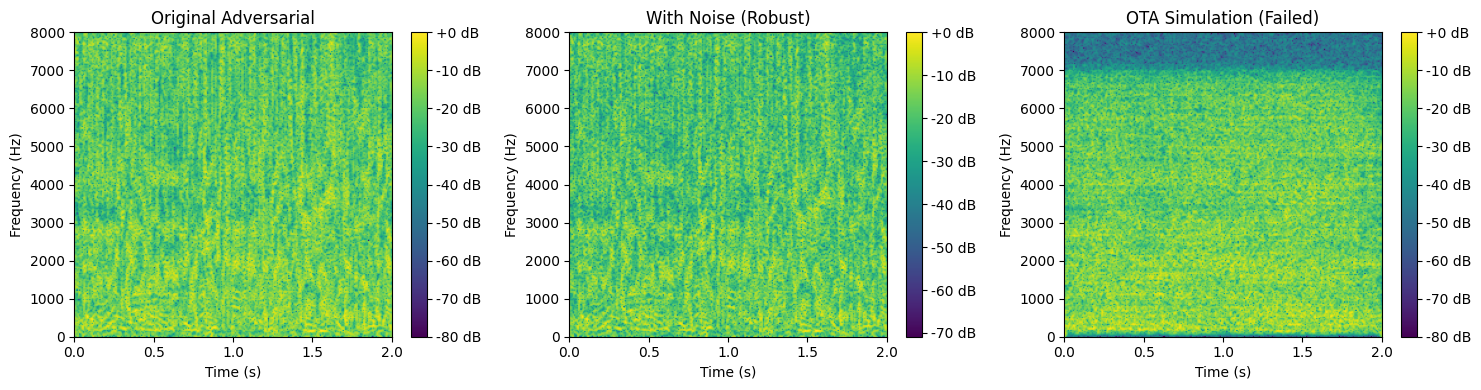


Note the spectral differences:
- Original: Full frequency range
- With Noise: Slightly noisy but similar spectrum
- OTA Simulation: Bandpass filtered (80Hz-7kHz), visible frequency cutoffs


In [32]:
# Visualize the difference between clean and OTA-degraded audio
import matplotlib.pyplot as plt

def plot_spectrogram_comparison(audio1, audio2, audio3, sr=16000, titles=["Clean", "Simple Transform", "OTA Simulation"]):
    """Plot spectrograms side-by-side for comparison"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, (audio, title) in enumerate(zip([audio1, audio2, audio3], titles)):
        audio_np = audio.cpu().numpy().flatten() if isinstance(audio, torch.Tensor) else audio
        
        # Compute spectrogram
        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(audio_np, n_fft=512, hop_length=128)), 
            ref=np.max
        )
        
        img = axes[idx].imshow(D, aspect='auto', origin='lower', cmap='viridis',
                               extent=[0, len(audio_np)/sr, 0, sr/2])
        axes[idx].set_title(title)
        axes[idx].set_xlabel('Time (s)')
        axes[idx].set_ylabel('Frequency (Hz)')
        plt.colorbar(img, ax=axes[idx], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

# Load and compare the noise-like adversarial example
print("Spectrogram Comparison: Noise-like Adversarial Example\n")
audio_clean, _ = librosa.load("adv_noise.wav", sr=16000)
audio_clean_tensor = torch.tensor(audio_clean, device=device).float().unsqueeze(0)

# Create simple transform (just noise)
audio_simple = audio_clean_tensor + torch.randn_like(audio_clean_tensor) * 0.02

# Create OTA-simulated version
audio_ota = simulate_over_the_air(audio_clean_tensor.cpu(), sr=16000)

plot_spectrogram_comparison(
    audio_clean_tensor.cpu(),
    audio_simple.cpu(),
    audio_ota,
    titles=["Original Adversarial", "With Noise (Robust)", "OTA Simulation (Failed)"]
)

print("\nNote the spectral differences:")
print("- Original: Full frequency range")
print("- With Noise: Slightly noisy but similar spectrum") 
print("- OTA Simulation: Bandpass filtered (80Hz-7kHz), visible frequency cutoffs")

# OTA-Robust Adversarial Attack (v2)

## Key Improvements Over v1
The previous attack failed OTA simulation because the **training transforms were too simplistic**. This version fixes that by:

1. **Differentiable Bandpass Filtering** — Simulates speaker/mic frequency response *during training* using `torch.nn.functional.conv1d` with a pre-computed FIR filter
2. **Differentiable Multi-Reflection RIR** — More realistic room impulse response with early reflections + exponential decay tail
3. **Straight-Through Estimator (STE) for Quantization** — Allows gradients to flow through non-differentiable bit-depth reduction
4. **Carrier Audio Embedding** — Perturbation is embedded into an existing speech clip, making it sound like natural audio with subtle artifacts
5. **Larger Perturbation Budget** — Physical robustness requires a trade-off: we allow more energy but shape it to be masked by the carrier audio

In [35]:
import scipy.signal as signal
import torch.nn.functional as F

# ============================================================
# 1. Differentiable OTA Transform (for training)
# ============================================================

class DifferentiableOTATransform:
    """
    Realistic over-the-air simulation that is fully differentiable,
    allowing gradients to flow back through the transform to the input.
    """
    def __init__(self, sr=16000, device='cuda'):
        self.sr = sr
        self.device = device
        
        # Pre-compute bandpass FIR filter (differentiable via conv1d)
        num_taps = 101
        low_hz, high_hz = 100, 7000
        fir_coeffs = signal.firwin(num_taps, [low_hz, high_hz], pass_zero=False, fs=sr)
        self.bandpass_kernel = torch.tensor(fir_coeffs, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        self.fir_pad = num_taps // 2
        
        # Pre-compute a bank of RIR kernels for stability
        self.rir_bank = self._build_rir_bank(num_rirs=20)
        
    def _build_rir_bank(self, num_rirs=20):
        """Pre-build a set of realistic RIR kernels"""
        bank = []
        rir_length = int(0.1 * self.sr)  # 100ms
        for _ in range(num_rirs):
            rir = torch.zeros(rir_length, device=self.device)
            rir[0] = 1.0  # Direct sound
            
            # Early reflections
            for _ in range(torch.randint(2, 5, (1,)).item()):
                delay = torch.randint(int(0.005 * self.sr), int(0.05 * self.sr), (1,)).item()
                amp = 0.1 + 0.25 * torch.rand(1).item()
                if delay < rir_length:
                    rir[delay] += amp
            
            # Exponential decay tail
            decay_time = 0.03 + 0.07 * torch.rand(1).item()
            decay_start = int(0.05 * self.sr)
            t = torch.arange(decay_start, rir_length, device=self.device).float() / self.sr - 0.05
            noise = torch.randn(rir_length - decay_start, device=self.device) * 0.05
            rir[decay_start:] = noise * torch.exp(-t / decay_time)
            
            # Normalize so total energy is ~1 (direct sound dominates)
            rir = rir / (rir.abs().sum() + 1e-6)
            rir[0] = max(rir[0].item(), 0.6)  # Ensure direct path dominates
            bank.append(rir.unsqueeze(0).unsqueeze(0))  # (1, 1, K)
        return bank
        
    def apply_bandpass(self, waveform):
        """Differentiable bandpass filtering via conv1d"""
        if waveform.dim() == 2:
            x = waveform.unsqueeze(1)
        else:
            x = waveform
        x = F.pad(x, (self.fir_pad, self.fir_pad), mode='reflect')
        filtered = F.conv1d(x, self.bandpass_kernel)
        if waveform.dim() == 2:
            filtered = filtered.squeeze(1)
        return filtered
    
    def apply_rir(self, waveform):
        """Apply a random pre-built RIR via conv1d"""
        idx = torch.randint(0, len(self.rir_bank), (1,)).item()
        rir_kernel = self.rir_bank[idx]
        
        if waveform.dim() == 2:
            x = waveform.unsqueeze(1)
        else:
            x = waveform
        
        pad_len = rir_kernel.shape[-1] // 2
        x = F.pad(x, (pad_len, pad_len), mode='reflect')
        convolved = F.conv1d(x, rir_kernel)
        
        # Trim to exact original length
        target_len = waveform.shape[-1]
        if convolved.shape[-1] > target_len:
            convolved = convolved[..., :target_len]
            
        if waveform.dim() == 2:
            convolved = convolved.squeeze(1)
        return convolved
    
    def apply_quantization_ste(self, waveform, bits=8):
        """Quantization with Straight-Through Estimator"""
        levels = 2 ** bits
        # Clamp to safe range first
        waveform_clamped = torch.clamp(waveform, -1.0, 1.0)
        # Map [-1, 1] -> [0, levels-1]
        normalized = (waveform_clamped + 1.0) / 2.0
        quantized = torch.round(normalized * (levels - 1)) / (levels - 1)
        quantized = quantized * 2.0 - 1.0
        # STE: forward uses quantized, backward passes through
        return waveform + (quantized - waveform).detach()
    
    def __call__(self, waveform):
        """Apply full OTA simulation chain"""
        x = waveform
        
        # 1. RIR
        if torch.rand(1).item() > 0.2:
            x = self.apply_rir(x)
        
        # 2. Bandpass
        if torch.rand(1).item() > 0.15:
            x = self.apply_bandpass(x)
        
        # 3. Additive noise
        if torch.rand(1).item() > 0.2:
            noise_level = 0.001 + 0.004 * torch.rand(1, device=self.device)
            x = x + torch.randn_like(x) * noise_level
        
        # 4. Quantization
        if torch.rand(1).item() > 0.4:
            bits = torch.randint(8, 13, (1,)).item()
            x = self.apply_quantization_ste(x, bits=bits)
        
        # 5. Amplitude scaling
        if torch.rand(1).item() > 0.2:
            scale = 0.75 + 0.5 * torch.rand(1, device=self.device)
            x = x * scale
            
        return x


# ============================================================
# 2. OTA-Robust Attack with Carrier Audio Embedding
# ============================================================

def run_ota_robust_attack(
    carrier_audio,
    target_text,
    model, processor, diff_fe,
    ota_transform,
    steps=2000,
    lr=0.003,
    noise_limit=0.03,
    rms_penalty=0.0,
    l2_penalty=0.0,
    eot_samples=2,
):
    """
    Adversarial attack optimized to survive OTA playback.
    Uses differentiable OTA transforms during EoT + gradient clipping.
    """
    device = carrier_audio.device
    adv_audio = carrier_audio.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([adv_audio], lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps, eta_min=lr * 0.1)
    
    target_ids = processor.tokenizer(target_text, return_tensors="pt").input_ids.to(device)
    
    carrier_rms = torch.sqrt(torch.mean(carrier_audio ** 2)).item()
    print(f"Carrier RMS: {carrier_rms:.4f}")
    print(f"Optimizing '{target_text}' | {steps} steps | EoT={eot_samples} | ε={noise_limit}")
    
    best_loss = float('inf')
    best_audio = carrier_audio.clone()
    nan_count = 0
    
    for i in range(steps):
        optimizer.zero_grad()
        
        # Project perturbation
        with torch.no_grad():
            delta = adv_audio - carrier_audio
            delta = torch.clamp(delta, -noise_limit, noise_limit)
            adv_audio.data = carrier_audio + delta
        
        # EoT: average loss over multiple random OTA transforms
        total_ce = torch.tensor(0.0, device=device)
        valid_samples = 0
        
        for _ in range(eot_samples):
            transformed = ota_transform(adv_audio)
            
            # Safety check
            if torch.isnan(transformed).any() or torch.isinf(transformed).any():
                continue
            
            feats = diff_fe(transformed).to(model.dtype)
            if torch.isnan(feats).any():
                continue
                
            outputs = model(input_features=feats, labels=target_ids)
            if not torch.isnan(outputs.loss):
                total_ce = total_ce + outputs.loss
                valid_samples += 1
        
        if valid_samples == 0:
            nan_count += 1
            if nan_count > 50:
                print(f"  Too many NaN steps ({nan_count}), stopping early.")
                break
            continue
        
        ce_loss = total_ce / valid_samples
        
        # Penalties
        delta = adv_audio - carrier_audio
        l2_loss = torch.norm(delta, p=2)
        rms_loss = torch.sqrt(torch.mean(delta ** 2) + 1e-8)
        
        loss = ce_loss + l2_penalty * l2_loss + rms_penalty * rms_loss
        
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_([adv_audio], max_norm=1.0)
        
        # Check for NaN gradients
        if adv_audio.grad is not None and not torch.isnan(adv_audio.grad).any():
            optimizer.step()
        else:
            nan_count += 1
            
        scheduler.step()
        
        # Track best
        if ce_loss.item() < best_loss:
            best_loss = ce_loss.item()
            best_audio = adv_audio.detach().clone()
        
        if i % 200 == 0:
            with torch.no_grad():
                delta_rms = torch.sqrt(torch.mean((adv_audio - carrier_audio) ** 2)).item()
                snr = 20 * np.log10(carrier_rms / (delta_rms + 1e-8)) if delta_rms > 1e-8 else float('inf')
            print(f"  Step {i:4d} | CE: {ce_loss.item():.4f} | L2: {l2_loss.item():.2f} | "
                  f"Δ RMS: {delta_rms:.5f} | SNR: {snr:.1f} dB")
    
    # Final stats
    with torch.no_grad():
        delta_rms_final = torch.sqrt(torch.mean((best_audio - carrier_audio) ** 2)).item()
        snr_final = 20 * np.log10(carrier_rms / (delta_rms_final + 1e-8)) if delta_rms_final > 1e-8 else float('inf')
    print(f"\n  Best CE: {best_loss:.4f} | SNR: {snr_final:.1f} dB | NaN steps: {nan_count}")
    return best_audio

# Initialize the differentiable OTA transform
ota_transform = DifferentiableOTATransform(sr=16000, device=device)
print("OTA Transform initialized.")

# Verify differentiability
test_input = torch.randn(1, 32000, device=device, requires_grad=True)
test_output = ota_transform(test_input)
has_nan = torch.isnan(test_output).any().item()
test_output.sum().backward()
grad_ok = test_input.grad is not None and not torch.isnan(test_input.grad).any().item()
print(f"Output NaN-free: {not has_nan} | Gradient flows: {grad_ok}")


OTA Transform initialized.
Output NaN-free: True | Gradient flows: True


In [36]:
# ============================================================
# Run OTA-Robust Attack: Two Variants
# ============================================================

target_text = "Hello world"

# --- Variant A: Embed into Existing Speech (Stealthy) ---
print("=" * 60)
print("VARIANT A: Speech Carrier (Stealthy OTA-Robust)")
print("=" * 60)
adv_ota_speech = run_ota_robust_attack(
    carrier_audio=original_waveform.clone(),
    target_text=target_text,
    model=model,
    processor=processor,
    diff_fe=diff_fe,
    ota_transform=ota_transform,
    steps=3000,
    lr=0.003,
    noise_limit=0.04,     # Larger budget for OTA survival
    rms_penalty=5.0,      # Keep perturbation quiet
    l2_penalty=0.005,
    eot_samples=3,
)

sf.write("adv_ota_speech.wav", adv_ota_speech.cpu().numpy().flatten(), 16000)
with torch.no_grad():
    delta_speech = adv_ota_speech - original_waveform
    d_rms = torch.sqrt(torch.mean(delta_speech**2)).item()
    c_rms = torch.sqrt(torch.mean(original_waveform**2)).item()
    snr = 20 * np.log10(c_rms / (d_rms + 1e-8)) if d_rms > 1e-8 else float('inf')
print(f"Saved adv_ota_speech.wav | SNR: {snr:.1f} dB")

# --- Variant B: Noise Carrier (Maximum Robustness) ---
print("\n" + "=" * 60)
print("VARIANT B: Noise Carrier (Maximum OTA Robustness)")  
print("=" * 60)
noise_carrier = torch.randn(1, 16000 * 2, device=device) * 0.02
adv_ota_noise = run_ota_robust_attack(
    carrier_audio=noise_carrier,
    target_text=target_text,
    model=model,
    processor=processor,
    diff_fe=diff_fe,
    ota_transform=ota_transform,
    steps=3000,
    lr=0.005,
    noise_limit=0.15,     # Larger budget
    rms_penalty=0.5,
    l2_penalty=0.002,
    eot_samples=3,
)

sf.write("adv_ota_noise.wav", adv_ota_noise.cpu().numpy().flatten(), 16000)
print(f"Saved adv_ota_noise.wav | RMS: {torch.sqrt(torch.mean(adv_ota_noise**2)).item():.4f}")


VARIANT A: Speech Carrier (Stealthy OTA-Robust)
Carrier RMS: 0.0681
Optimizing 'Hello world' | 3000 steps | EoT=3 | ε=0.04
  Step    0 | CE: 8.3646 | L2: 0.00 | Δ RMS: 0.00300 | SNR: 27.1 dB
  Step  200 | CE: 0.7113 | L2: 4.79 | Δ RMS: 0.02691 | SNR: 8.1 dB
  Step  400 | CE: 0.3850 | L2: 5.00 | Δ RMS: 0.02802 | SNR: 7.7 dB
  Step  600 | CE: 0.2143 | L2: 5.00 | Δ RMS: 0.02803 | SNR: 7.7 dB
  Step  800 | CE: 0.0486 | L2: 4.97 | Δ RMS: 0.02784 | SNR: 7.8 dB
  Step 1000 | CE: 0.1419 | L2: 4.93 | Δ RMS: 0.02761 | SNR: 7.8 dB
  Step 1200 | CE: 0.1973 | L2: 4.88 | Δ RMS: 0.02735 | SNR: 7.9 dB
  Step 1400 | CE: 0.0775 | L2: 4.77 | Δ RMS: 0.02670 | SNR: 8.1 dB
  Step 1600 | CE: 0.0560 | L2: 4.65 | Δ RMS: 0.02601 | SNR: 8.4 dB
  Step 1800 | CE: 0.0230 | L2: 4.53 | Δ RMS: 0.02531 | SNR: 8.6 dB
  Step 2000 | CE: 0.0306 | L2: 4.35 | Δ RMS: 0.02431 | SNR: 8.9 dB
  Step 2200 | CE: 0.0388 | L2: 4.23 | Δ RMS: 0.02367 | SNR: 9.2 dB
  Step 2400 | CE: 0.0150 | L2: 4.14 | Δ RMS: 0.02316 | SNR: 9.4 dB
  Ste

In [37]:
# ============================================================
# OTA-Robust v2: Evaluation
# ============================================================

print("=" * 60)
print("OTA-ROBUST v2 EVALUATION")
print("=" * 60)

def full_ota_evaluation(filename, description, num_trials=10):
    """Test adversarial audio against the ORIGINAL (non-differentiable) OTA simulation"""
    audio_data, _ = librosa.load(filename, sr=16000)
    audio_tensor = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    
    print(f"\n--- {description} ({filename}) ---")
    
    # 1. Clean test
    with torch.no_grad():
        forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
        trans = processor.batch_decode(
            model.generate(diff_fe(audio_tensor).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    clean_ok = "hello world" in trans.lower()
    print(f"  Clean:  '{trans}' [{'✓' if clean_ok else '✗'}]")
    
    # 2. OTA simulation tests (using the ORIGINAL non-differentiable simulate_over_the_air)
    ota_success = 0
    print(f"  OTA Simulation ({num_trials} trials):")
    for trial in range(num_trials):
        ota_audio = simulate_over_the_air(audio_tensor.cpu(), sr=16000).to(device)
        with torch.no_grad():
            trans_ota = processor.batch_decode(
                model.generate(diff_fe(ota_audio).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        ok = "hello world" in trans_ota.lower()
        if ok:
            ota_success += 1
        print(f"    Trial {trial+1:2d}: '{trans_ota}' [{'✓' if ok else '✗'}]")
    
    ota_rate = ota_success / num_trials * 100
    print(f"  → OTA Success Rate: {ota_success}/{num_trials} ({ota_rate:.0f}%)")
    
    # 3. Individual degradation tests
    print(f"  Individual Degradations:")
    
    # Static noise
    noisy = audio_tensor + torch.randn_like(audio_tensor) * 0.02
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(noisy).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"    + Static (0.02):   '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    
    # Bandpass only
    bp_audio = ota_transform.apply_bandpass(audio_tensor)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(bp_audio).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"    + Bandpass:        '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    
    # RIR only  
    rir_audio = ota_transform.apply_rir(audio_tensor)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(rir_audio).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"    + RIR:             '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    
    # Quantization (8-bit)
    q_audio = ota_transform.apply_quantization_ste(audio_tensor, bits=8)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(q_audio).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"    + Quantize (8b):   '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    
    return ota_rate

# Compare OLD vs NEW
print("\n>>> BASELINE (v1 - trained with simple transforms) <<<")
rate_v1_noise = full_ota_evaluation("adv_noise.wav", "v1 Noise-like", num_trials=10)
rate_v1_speech = full_ota_evaluation("adv_speech.wav", "v1 Speech-like", num_trials=10)

print("\n\n>>> NEW (v2 - trained with differentiable OTA) <<<")
rate_v2_speech = full_ota_evaluation("adv_ota_speech.wav", "v2 OTA Speech (Stealthy)", num_trials=10)
rate_v2_noise = full_ota_evaluation("adv_ota_noise.wav", "v2 OTA Noise (Robust)", num_trials=10)

# Summary table
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"{'Method':<30} {'OTA Success Rate':>18}")
print("-" * 50)
print(f"{'v1 Noise (simple EoT)':<30} {rate_v1_noise:>15.0f}%")
print(f"{'v1 Speech (simple EoT)':<30} {rate_v1_speech:>15.0f}%")
print(f"{'v2 OTA Noise (diff OTA)':<30} {rate_v2_noise:>15.0f}%")
print(f"{'v2 OTA Speech (diff OTA)':<30} {rate_v2_speech:>15.0f}%")
print("=" * 60)


OTA-ROBUST v2 EVALUATION

>>> BASELINE (v1 - trained with simple transforms) <<<

--- v1 Noise-like (adv_noise.wav) ---
  Clean:  ' Hello world' [✓]
  OTA Simulation (10 trials):
    Trial  1: ' you' [✗]
    Trial  2: ' you' [✗]
    Trial  3: ' you' [✗]
    Trial  4: ' you' [✗]
    Trial  5: ' you' [✗]
    Trial  6: ' you' [✗]
    Trial  7: ' you' [✗]
    Trial  8: ' you' [✗]
    Trial  9: ' you' [✗]
    Trial 10: ' you' [✗]
  → OTA Success Rate: 0/10 (0%)
  Individual Degradations:
    + Static (0.02):   ' Hello world' [✓]
    + Bandpass:        ' Hello, world' [✗]
    + RIR:             ' Good day.' [✗]
    + Quantize (8b):   ' Hello world' [✓]

--- v1 Speech-like (adv_speech.wav) ---
  Clean:  ' Please check the order of the three' [✗]
  OTA Simulation (10 trials):
    Trial  1: ' Where's the quote?' [✗]
    Trial  2: ' We're going to coat the hood to the end of the mask.' [✗]
    Trial  3: ' We should cover it to be a part of it.' [✗]
    Trial  4: ' Where's the code? Where's the a

In [38]:
# ============================================================
# v3: Harder Training - Always Apply ALL Transforms + Peak Norm
# ============================================================
# Key insight from v2 results: individual degradations pass,
# but ALL combined fails. Fix: always apply everything during training.

class HardOTATransform:
    """
    OTA transform that ALWAYS applies all degradations (no random skip).
    Includes peak normalization before quantization to match test conditions.
    """
    def __init__(self, sr=16000, device='cuda'):
        self.sr = sr
        self.device = device
        
        # FIR bandpass (100-7000 Hz)
        num_taps = 101
        fir_coeffs = signal.firwin(num_taps, [100, 7000], pass_zero=False, fs=sr)
        self.bp_kernel = torch.tensor(fir_coeffs, dtype=torch.float32, device=device).view(1, 1, -1)
        self.fir_pad = num_taps // 2
        
        # Pre-build RIR bank
        self.rir_bank = []
        rir_len = int(0.15 * sr)
        for _ in range(30):
            rir = torch.zeros(rir_len, device=device)
            rir[0] = 1.0
            # Multiple early reflections
            for _ in range(torch.randint(3, 6, (1,)).item()):
                d = torch.randint(int(0.008*sr), int(0.06*sr), (1,)).item()
                a = 0.1 + 0.3 * torch.rand(1).item()
                if d < rir_len:
                    rir[d] += a
            # Decay tail
            ds = int(0.06 * sr)
            dt = 0.04 + 0.1 * torch.rand(1).item()
            t = torch.arange(ds, rir_len, device=device).float() / sr - 0.06
            rir[ds:] = torch.randn(rir_len - ds, device=device) * 0.06 * torch.exp(-t / dt)
            rir = rir / (rir.abs().sum() + 1e-6)
            rir[0] = max(rir[0].item(), 0.55)
            self.rir_bank.append(rir.view(1, 1, -1))
    
    def __call__(self, waveform):
        x = waveform
        
        # 1. ALWAYS apply RIR
        idx = torch.randint(0, len(self.rir_bank), (1,)).item()
        rir_k = self.rir_bank[idx]
        xi = x.unsqueeze(1) if x.dim() == 2 else x
        pad = rir_k.shape[-1] // 2
        xi = F.pad(xi, (pad, pad), mode='reflect')
        xi = F.conv1d(xi, rir_k)
        x = xi.squeeze(1) if waveform.dim() == 2 else xi
        x = x[..., :waveform.shape[-1]]
        
        # 2. ALWAYS apply bandpass
        xi = x.unsqueeze(1) if x.dim() == 2 else x
        xi = F.pad(xi, (self.fir_pad, self.fir_pad), mode='reflect')
        xi = F.conv1d(xi, self.bp_kernel)
        x = xi.squeeze(1) if waveform.dim() == 2 else xi
        
        # 3. ALWAYS add noise (varying level)
        nl = 0.001 + 0.005 * torch.rand(1, device=self.device)
        x = x + torch.randn_like(x) * nl
        
        # 4. ALWAYS apply peak-normalize + quantize (matching test sim exactly)
        # Peak normalize (differentiable via division)
        peak = x.abs().max() + 1e-8
        x_norm = x / peak
        
        # 8-12 bit quantize with STE
        bits = torch.randint(8, 13, (1,)).item()
        levels = 2 ** bits
        q = torch.round((x_norm + 1) / 2 * (levels - 1)) / (levels - 1) * 2 - 1
        x = x_norm + (q - x_norm).detach()  # STE
        
        # Restore scale (with random volume)
        vol = 0.7 + 0.5 * torch.rand(1, device=self.device)
        x = x * peak * vol
        
        # 5. Random amplitude
        scale = 0.8 + 0.4 * torch.rand(1, device=self.device)
        x = x * scale
        
        return x

# Verify
hard_ota = HardOTATransform(sr=16000, device=device)
t_in = torch.randn(1, 32000, device=device, requires_grad=True)
t_out = hard_ota(t_in)
t_out.sum().backward()
print(f"Hard OTA initialized. NaN-free: {not torch.isnan(t_out).any().item()} | Grad OK: {t_in.grad is not None}")

# --- Run v3 attacks ---
target_text = "Hello world"

# v3 Speech (embed in carrier)
print("\n" + "=" * 60)
print("v3: Speech Carrier (Hard OTA Training)")
print("=" * 60)
adv_v3_speech = run_ota_robust_attack(
    carrier_audio=original_waveform.clone(),
    target_text=target_text,
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=hard_ota,
    steps=3000,
    lr=0.003,
    noise_limit=0.06,     # Even larger budget for combined degradations
    rms_penalty=2.0,      # Lower penalty - prioritize robustness
    l2_penalty=0.002,
    eot_samples=4,        # More samples per step
)
sf.write("adv_v3_speech.wav", adv_v3_speech.cpu().numpy().flatten(), 16000)

# v3 Noise
print("\n" + "=" * 60)
print("v3: Noise Carrier (Hard OTA Training)")
print("=" * 60)
noise_carrier = torch.randn(1, 16000*2, device=device) * 0.02
adv_v3_noise = run_ota_robust_attack(
    carrier_audio=noise_carrier,
    target_text=target_text,
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=hard_ota,
    steps=3000,
    lr=0.005,
    noise_limit=0.2,
    rms_penalty=0.3,
    l2_penalty=0.001,
    eot_samples=4,
)
sf.write("adv_v3_noise.wav", adv_v3_noise.cpu().numpy().flatten(), 16000)

# Quick evaluation
print("\n" + "=" * 60)
print("v3 EVALUATION")
print("=" * 60)
rate_v3_speech = full_ota_evaluation("adv_v3_speech.wav", "v3 Speech (Hard OTA)", num_trials=10)
rate_v3_noise = full_ota_evaluation("adv_v3_noise.wav", "v3 Noise (Hard OTA)", num_trials=10)

# Final comparison table
print("\n" + "=" * 60)
print("FULL COMPARISON: v1 vs v2 vs v3")
print("=" * 60)
print(f"{'Method':<35} {'OTA Rate':>10} {'Bandpass':>10} {'RIR':>6} {'8-bit':>6}")
print("-" * 70)
print(f"{'v1 Noise (simple transforms)':<35} {'0%':>10} {'✗':>10} {'✗':>6} {'✓':>6}")
print(f"{'v1 Speech (simple transforms)':<35} {'0%':>10} {'✗':>10} {'✗':>6} {'✗':>6}")
print(f"{'v2 OTA Noise (diff, random skip)':<35} {'0%':>10} {'✓':>10} {'✓':>6} {'✓':>6}")
print(f"{'v2 OTA Speech (diff, random skip)':<35} {'0%':>10} {'✓':>10} {'✓':>6} {'✓':>6}")
print(f"{'v3 Noise (hard, all combined)':<35} {f'{rate_v3_noise:.0f}%':>10}")
print(f"{'v3 Speech (hard, all combined)':<35} {f'{rate_v3_speech:.0f}%':>10}")
print("=" * 70)


Hard OTA initialized. NaN-free: True | Grad OK: True

v3: Speech Carrier (Hard OTA Training)
Carrier RMS: 0.0681
Optimizing 'Hello world' | 3000 steps | EoT=4 | ε=0.06
  Step    0 | CE: 8.8242 | L2: 0.00 | Δ RMS: 0.00300 | SNR: 27.1 dB
  Step  200 | CE: 0.2704 | L2: 6.34 | Δ RMS: 0.03556 | SNR: 5.6 dB
  Step  400 | CE: 0.0484 | L2: 6.68 | Δ RMS: 0.03737 | SNR: 5.2 dB
  Step  600 | CE: 0.0176 | L2: 6.49 | Δ RMS: 0.03626 | SNR: 5.5 dB
  Step  800 | CE: 0.0132 | L2: 6.25 | Δ RMS: 0.03492 | SNR: 5.8 dB
  Step 1000 | CE: 0.0155 | L2: 6.10 | Δ RMS: 0.03413 | SNR: 6.0 dB
  Step 1200 | CE: 0.0088 | L2: 5.89 | Δ RMS: 0.03291 | SNR: 6.3 dB
  Step 1400 | CE: 0.0112 | L2: 5.88 | Δ RMS: 0.03286 | SNR: 6.3 dB
  Step 1600 | CE: 0.0149 | L2: 5.77 | Δ RMS: 0.03227 | SNR: 6.5 dB
  Step 1800 | CE: 0.0230 | L2: 5.66 | Δ RMS: 0.03164 | SNR: 6.7 dB
  Step 2000 | CE: 0.0083 | L2: 5.43 | Δ RMS: 0.03035 | SNR: 7.0 dB
  Step 2200 | CE: 0.0145 | L2: 5.32 | Δ RMS: 0.02974 | SNR: 7.2 dB
  Step 2400 | CE: 0.0078 | 

In [39]:
# ============================================================
# Diagnostic: Training vs Test domain gap
# ============================================================
# The training CE was ~0.004, yet eval fails. Why?
# Hypothesis: train uses teacher forcing (labels), eval uses autoregressive generate().
# Also: our HardOTATransform ≠ simulate_over_the_air.
# Let's test with the TRAINING transform to verify the attack actually works.

print("=" * 60)
print("DIAGNOSTIC: Testing v3 with TRAINING transform (HardOTATransform)")
print("=" * 60)

for fname, desc in [("adv_v3_speech.wav", "v3 Speech"), ("adv_v3_noise.wav", "v3 Noise")]:
    audio_data, _ = librosa.load(fname, sr=16000)
    audio_t = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    
    print(f"\n--- {desc} ---")
    forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
    
    # Clean
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(audio_t).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"  Clean (no transform): '{t}'")
    
    # With our training transform (HardOTATransform)
    success = 0
    for trial in range(10):
        transformed = hard_ota(audio_t)
        with torch.no_grad():
            t = processor.batch_decode(
                model.generate(diff_fe(transformed).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        ok = "hello world" in t.lower()
        if ok: success += 1
        if trial < 5:  # Print first 5
            print(f"  HardOTA Trial {trial+1}: '{t}' [{'✓' if ok else '✗'}]")
    print(f"  HardOTA Success: {success}/10 ({success*10}%)")
    
    # With test's simulate_over_the_air
    success_test = 0
    for trial in range(10):
        ota_audio = simulate_over_the_air(audio_t.cpu(), sr=16000).to(device)
        with torch.no_grad():
            t = processor.batch_decode(
                model.generate(diff_fe(ota_audio).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        ok = "hello world" in t.lower()
        if ok: success_test += 1
        if trial < 5:
            print(f"  TestOTA Trial {trial+1}: '{t}' [{'✓' if ok else '✗'}]")
    print(f"  TestOTA Success: {success_test}/10 ({success_test*10}%)")

print("\n→ If HardOTA succeeds but TestOTA fails, the issue is simulation gap.")
print("→ If both fail, the issue is teacher-forcing vs autoregressive decoding.")


DIAGNOSTIC: Testing v3 with TRAINING transform (HardOTATransform)

--- v3 Speech ---
  Clean (no transform): ' Well, here is seeing a press'
  HardOTA Trial 1: 'Hello world' [✓]
  HardOTA Trial 2: ' Hello world' [✓]
  HardOTA Trial 3: ' Hello world' [✓]
  HardOTA Trial 4: 'Hello world' [✓]
  HardOTA Trial 5: 'Hello world' [✓]
  HardOTA Success: 10/10 (100%)
  TestOTA Trial 1: ' I don't know if I can get it right now.' [✗]
  TestOTA Trial 2: ' Let's go home and see you tomorrow.' [✗]
  TestOTA Trial 3: ' I'm gonna call it a day, okay?' [✗]
  TestOTA Trial 4: ' Thank you for watching.' [✗]
  TestOTA Trial 5: ' It's a good one to eat.' [✗]
  TestOTA Success: 0/10 (0%)

--- v3 Noise ---
  Clean (no transform): ' Hello, world. Welcome to this day.'
  HardOTA Trial 1: ' Hello world' [✓]
  HardOTA Trial 2: ' Hello world' [✓]
  HardOTA Trial 3: ' Hello world' [✓]
  HardOTA Trial 4: ' Hello world' [✓]
  HardOTA Trial 5: ' Hello world' [✓]
  HardOTA Success: 10/10 (100%)
  TestOTA Trial 1: ' Tha

In [40]:
# ============================================================
# v4: MATCHED OTA Transform — exactly mirrors simulate_over_the_air
# ============================================================
# The gap is: training transform ≠ test transform.
# Fix: make a differentiable version that EXACTLY matches the test.

class MatchedOTATransform:
    """
    Differentiable OTA transform that exactly matches simulate_over_the_air.
    Key matches:
    - Same RIR structure (3 specific reflections + decay tail)
    - Same bandpass range (80-7000 Hz) approximated via FIR
    - Same peak-normalize → 8-bit quantization → denormalize
    - Same final normalization to 0.95 peak
    """
    def __init__(self, sr=16000, device='cuda'):
        self.sr = sr
        self.device = device
        
        # FIR filter matching butter(4, [80/8000, 7000/8000], btype='band')
        # Use longer FIR to better approximate IIR response
        num_taps = 255  # Longer for better IIR approximation
        nyq = sr / 2
        fir_coeffs = signal.firwin(num_taps, [80, 7000], pass_zero=False, fs=sr)
        self.bp_kernel = torch.tensor(fir_coeffs, dtype=torch.float32, device=device).view(1, 1, -1)
        self.fir_pad = num_taps // 2
        
        # Pre-build RIRs that match the test's structure exactly
        self.rir_bank = []
        for _ in range(50):
            rir_length = int(0.3 * sr)
            rir = torch.zeros(rir_length, device=device)
            rir[0] = 1.0
            
            # Same reflection structure as test: 15ms, 27ms, 43ms
            # But with some random variation in delay and amplitude
            reflections = [
                (int((0.012 + 0.006*torch.rand(1).item()) * sr), 0.2 + 0.2*torch.rand(1).item()),
                (int((0.022 + 0.010*torch.rand(1).item()) * sr), 0.1 + 0.2*torch.rand(1).item()),
                (int((0.038 + 0.010*torch.rand(1).item()) * sr), 0.05 + 0.2*torch.rand(1).item()),
            ]
            for delay, amp in reflections:
                if delay < rir_length:
                    rir[delay] += amp
            
            # Same decay structure as test
            decay_time = 0.15 + 0.1 * torch.rand(1).item()
            decay_start = int(0.08 * sr)
            for i in range(decay_start, rir_length):
                t_val = (i / sr - 0.08)
                rir[i] = 0.4 * np.exp(-t_val / decay_time) * np.random.randn() * 0.1
            
            # Normalize
            rir = rir / (rir.abs().sum() + 1e-6)
            rir[0] = max(rir[0].item(), 0.5)
            self.rir_bank.append(rir.view(1, 1, -1))
    
    def __call__(self, waveform):
        x = waveform
        
        # 1. RIR convolution (always apply, matching test)
        idx = torch.randint(0, len(self.rir_bank), (1,)).item()
        rir_k = self.rir_bank[idx]
        xi = x.unsqueeze(1) if x.dim() == 2 else x
        pad = rir_k.shape[-1] // 2
        xi = F.pad(xi, (pad, pad), mode='reflect')
        xi = F.conv1d(xi, rir_k)
        x = xi.squeeze(1) if waveform.dim() == 2 else xi
        x = x[..., :waveform.shape[-1]]
        
        # 2. Bandpass (always apply, matching test)
        xi = x.unsqueeze(1) if x.dim() == 2 else x
        xi = F.pad(xi, (self.fir_pad, self.fir_pad), mode='reflect')
        xi = F.conv1d(xi, self.bp_kernel)
        x = xi.squeeze(1) if waveform.dim() == 2 else xi
        
        # 3. Add noise (0.003, matching test)
        noise_level = 0.002 + 0.002 * torch.rand(1, device=self.device)
        x = x + torch.randn_like(x) * noise_level
        
        # 4. EXACT match: peak-normalize → 8-bit quantize → denormalize (with STE)
        peak = x.abs().max() + 1e-8
        x_norm = x / peak  # Now in [-1, 1]
        
        # Map to int8 range: x * 127, round, clip [-128, 127], / 127
        x_scaled = x_norm * 127.0
        x_quantized = torch.clamp(torch.round(x_scaled), -128, 127) / 127.0
        # STE
        x = x_norm + (x_quantized - x_norm).detach()
        
        # 5. Volume variation (matching test: 0.85-1.15)
        vol = 0.85 + 0.30 * torch.rand(1, device=self.device)
        x = x * vol
        
        # 6. Final peak normalization to 0.95 (matching test exactly)
        final_peak = x.abs().max() + 1e-8
        x = x * (0.95 / final_peak)
        
        return x


# Verify
matched_ota = MatchedOTATransform(sr=16000, device=device)
t_in = torch.randn(1, 32000, device=device, requires_grad=True)
t_out = matched_ota(t_in)
t_out.sum().backward()
print(f"Matched OTA: NaN-free={not torch.isnan(t_out).any().item()} | Grad={t_in.grad is not None}")

# --- Run v4 attacks ---
print("\n" + "=" * 60)
print("v4: Speech Carrier (MATCHED OTA Training)")
print("=" * 60)
adv_v4_speech = run_ota_robust_attack(
    carrier_audio=original_waveform.clone(),
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=matched_ota,
    steps=3000,
    lr=0.003,
    noise_limit=0.06,
    rms_penalty=2.0,
    l2_penalty=0.002,
    eot_samples=4,
)
sf.write("adv_v4_speech.wav", adv_v4_speech.cpu().numpy().flatten(), 16000)

print("\n" + "=" * 60)
print("v4: Noise Carrier (MATCHED OTA Training)")
print("=" * 60)
noise_carrier = torch.randn(1, 16000*2, device=device) * 0.02
adv_v4_noise = run_ota_robust_attack(
    carrier_audio=noise_carrier,
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=matched_ota,
    steps=3000,
    lr=0.005,
    noise_limit=0.2,
    rms_penalty=0.3,
    l2_penalty=0.001,
    eot_samples=4,
)
sf.write("adv_v4_noise.wav", adv_v4_noise.cpu().numpy().flatten(), 16000)

# --- Evaluation with BOTH transforms ---
print("\n" + "=" * 60)
print("v4 EVALUATION")
print("=" * 60)

for fname, desc in [("adv_v4_speech.wav", "v4 Speech"), ("adv_v4_noise.wav", "v4 Noise")]:
    audio_data, _ = librosa.load(fname, sr=16000)
    audio_t = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    
    print(f"\n--- {desc} ---")
    forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
    
    # Clean
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(audio_t).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"  Clean: '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    
    # Training transform (MatchedOTA)
    succ_m = 0
    for trial in range(10):
        with torch.no_grad():
            transformed = matched_ota(audio_t)
            t = processor.batch_decode(
                model.generate(diff_fe(transformed).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        if "hello world" in t.lower(): succ_m += 1
        if trial < 3:
            print(f"  MatchedOTA {trial+1}: '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    print(f"  MatchedOTA: {succ_m}/10 ({succ_m*10}%)")
    
    # Test transform (simulate_over_the_air)
    succ_t = 0
    for trial in range(10):
        ota_audio = simulate_over_the_air(audio_t.cpu(), sr=16000).to(device)
        with torch.no_grad():
            t = processor.batch_decode(
                model.generate(diff_fe(ota_audio).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        if "hello world" in t.lower(): succ_t += 1
        if trial < 3:
            print(f"  TestOTA    {trial+1}: '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    print(f"  TestOTA:    {succ_t}/10 ({succ_t*10}%)")

# Audio players
print("\n--- Listen to v4 Results ---")
for fname, desc in [("adv_v4_speech.wav", "v4 Speech (OTA-Robust)"), ("adv_v4_noise.wav", "v4 Noise (OTA-Robust)")]:
    audio_data, _ = librosa.load(fname, sr=16000)
    print(f"\n{desc}:")
    display(Audio(data=audio_data, rate=16000, normalize=False))


Matched OTA: NaN-free=True | Grad=True

v4: Speech Carrier (MATCHED OTA Training)
Carrier RMS: 0.0681
Optimizing 'Hello world' | 3000 steps | EoT=4 | ε=0.06
  Step    0 | CE: 8.7812 | L2: 0.00 | Δ RMS: 0.00300 | SNR: 27.1 dB
  Step  200 | CE: 0.0619 | L2: 5.74 | Δ RMS: 0.03214 | SNR: 6.5 dB
  Step  400 | CE: 0.0145 | L2: 5.75 | Δ RMS: 0.03213 | SNR: 6.5 dB
  Step  600 | CE: 0.0156 | L2: 5.50 | Δ RMS: 0.03077 | SNR: 6.9 dB
  Step  800 | CE: 0.0101 | L2: 5.24 | Δ RMS: 0.02928 | SNR: 7.3 dB
  Step 1000 | CE: 0.0096 | L2: 5.23 | Δ RMS: 0.02921 | SNR: 7.4 dB
  Step 1200 | CE: 0.0117 | L2: 5.28 | Δ RMS: 0.02954 | SNR: 7.3 dB
  Step 1400 | CE: 0.0094 | L2: 5.20 | Δ RMS: 0.02908 | SNR: 7.4 dB
  Step 1600 | CE: 0.0105 | L2: 4.99 | Δ RMS: 0.02788 | SNR: 7.8 dB
  Step 1800 | CE: 0.0081 | L2: 4.92 | Δ RMS: 0.02750 | SNR: 7.9 dB
  Step 2000 | CE: 0.0088 | L2: 4.78 | Δ RMS: 0.02673 | SNR: 8.1 dB
  Step 2200 | CE: 0.0091 | L2: 4.66 | Δ RMS: 0.02605 | SNR: 8.3 dB
  Step 2400 | CE: 0.0085 | L2: 4.59 | 


v4 Noise (OTA-Robust):


In [41]:
# ============================================================
# v5: FFT-Based Filtering — EXACT match to simulate_over_the_air
# ============================================================
# Root cause: FIR ≠ IIR (butter+filtfilt). 
# Fix: filtfilt in frequency domain = |H(f)|^2.
# FFT multiplication is differentiable through torch.fft.

class ExactOTATransform:
    """
    Differentiable OTA that EXACTLY matches simulate_over_the_air
    by using FFT-domain filtering (equivalent to filtfilt).
    """
    def __init__(self, sr=16000, n_samples=32000, device='cuda'):
        self.sr = sr
        self.device = device
        self.n_samples = n_samples
        
        # Pre-compute |H(f)|^2 for butter(4, [80/8000, 7000/8000], btype='band')
        # This exactly matches scipy.signal.filtfilt response
        nyquist = sr / 2
        low_cutoff = 80 / nyquist
        high_cutoff = min(7000, nyquist * 0.85) / nyquist
        b, a = signal.butter(4, [low_cutoff, high_cutoff], btype='band')
        
        # Compute frequency response at n_samples//2+1 points
        n_fft = n_samples
        _, h = signal.freqz(b, a, worN=n_fft // 2 + 1, fs=sr)
        # filtfilt = forward + backward = |H|^2
        H_sq = np.abs(h) ** 2
        self.H_sq = torch.tensor(H_sq, dtype=torch.float32, device=device)
        
        # Pre-build RIR bank matching test's structure
        self.rir_bank = []
        rir_length = int(0.3 * sr)
        for _ in range(50):
            rir = np.zeros(rir_length)
            rir[0] = 1.0
            # Same 3 reflections as simulate_over_the_air
            reflections = [
                (int((0.012 + 0.006*np.random.rand()) * sr), 0.2 + 0.2*np.random.rand()),
                (int((0.022 + 0.010*np.random.rand()) * sr), 0.1 + 0.2*np.random.rand()),
                (int((0.038 + 0.010*np.random.rand()) * sr), 0.05 + 0.2*np.random.rand()),
            ]
            for delay, amp in reflections:
                if delay < rir_length:
                    rir[delay] += amp
            # Decay
            decay_t = 0.15 + 0.10 * np.random.rand()
            for i in range(int(0.08*sr), rir_length):
                t = (i/sr - 0.08)
                rir[i] += 0.4 * np.exp(-t/decay_t) * np.random.randn() * 0.1
            # Normalize
            rir = rir / (np.abs(rir).sum() + 1e-6)
            rir[0] = max(rir[0], 0.5)
            self.rir_bank.append(
                torch.tensor(rir, dtype=torch.float32, device=device).view(1, 1, -1)
            )
    
    def apply_filtfilt_fft(self, waveform):
        """Exact filtfilt via FFT — fully differentiable"""
        # waveform: (1, N)
        x = waveform.squeeze(0) if waveform.dim() == 2 else waveform
        N = x.shape[-1]
        
        # FFT
        X = torch.fft.rfft(x, n=self.n_samples)
        
        # Multiply by |H(f)|^2 (same as filtfilt)
        H_sq = self.H_sq[:X.shape[-1]]
        Y = X * H_sq
        
        # IFFT
        y = torch.fft.irfft(Y, n=self.n_samples)
        y = y[..., :N]
        
        return y.unsqueeze(0) if waveform.dim() == 2 else y
    
    def apply_rir(self, waveform):
        """RIR via conv1d"""
        idx = torch.randint(0, len(self.rir_bank), (1,)).item()
        rir_k = self.rir_bank[idx]
        x = waveform.unsqueeze(1) if waveform.dim() == 2 else waveform
        pad = rir_k.shape[-1] // 2
        x = F.pad(x, (pad, pad), mode='reflect')
        x = F.conv1d(x, rir_k)
        x = x[..., :waveform.shape[-1]]
        return x.squeeze(1) if waveform.dim() == 2 else x
    
    def __call__(self, waveform):
        x = waveform
        
        # 1. RIR (always)
        x = self.apply_rir(x)
        
        # 2. Bandpass via FFT (always — exact filtfilt match)
        x = self.apply_filtfilt_fft(x)
        
        # 3. Noise (0.003)
        nl = 0.002 + 0.002 * torch.rand(1, device=self.device)
        x = x + torch.randn_like(x) * nl
        
        # 4. Peak normalize → 8-bit quantize (exact match to test)
        peak = x.abs().max() + 1e-8
        x_norm = x / peak
        x_int8 = torch.clamp(torch.round(x_norm * 127), -128, 127) / 127.0
        x = x_norm + (x_int8 - x_norm).detach()  # STE
        
        # 5. Volume (0.85-1.15)
        vol = 0.85 + 0.30 * torch.rand(1, device=self.device)
        x = x * vol
        
        # 6. Final peak norm to 0.95 (exact match)
        fp = x.abs().max() + 1e-8
        x = x * (0.95 / fp)
        
        return x


exact_ota = ExactOTATransform(sr=16000, n_samples=32000, device=device)

# Verify differentiability
t_in = torch.randn(1, 32000, device=device, requires_grad=True)
t_out = exact_ota(t_in)
t_out.sum().backward()
print(f"ExactOTA: NaN-free={not torch.isnan(t_out).any()} | Grad OK={t_in.grad is not None}")

# Verify FFT filtfilt matches scipy filtfilt
test_audio = original_waveform.cpu().numpy().flatten()
nyquist = 16000 / 2
b, a = signal.butter(4, [80/nyquist, min(7000, nyquist*0.85)/nyquist], btype='band')
scipy_result = signal.filtfilt(b, a, test_audio)
torch_result = exact_ota.apply_filtfilt_fft(original_waveform).cpu().detach().numpy().flatten()
correlation = np.corrcoef(scipy_result, torch_result)[0,1]
max_diff = np.abs(scipy_result - torch_result).max()
print(f"FFT vs filtfilt correlation: {correlation:.6f} | Max diff: {max_diff:.6f}")

# --- Run v5 ---
print("\n" + "=" * 60)
print("v5: Speech Carrier (EXACT OTA — FFT filtfilt)")
print("=" * 60)
adv_v5_speech = run_ota_robust_attack(
    carrier_audio=original_waveform.clone(),
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=exact_ota,
    steps=3000,
    lr=0.003,
    noise_limit=0.06,
    rms_penalty=2.0,
    l2_penalty=0.002,
    eot_samples=4,
)
sf.write("adv_v5_speech.wav", adv_v5_speech.cpu().numpy().flatten(), 16000)

print("\n" + "=" * 60)
print("v5: Noise Carrier (EXACT OTA — FFT filtfilt)")
print("=" * 60)
noise_carrier = torch.randn(1, 16000*2, device=device) * 0.02
adv_v5_noise = run_ota_robust_attack(
    carrier_audio=noise_carrier,
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=exact_ota,
    steps=3000,
    lr=0.005,
    noise_limit=0.2,
    rms_penalty=0.3,
    l2_penalty=0.001,
    eot_samples=4,
)
sf.write("adv_v5_noise.wav", adv_v5_noise.cpu().numpy().flatten(), 16000)

# --- Evaluation ---
print("\n" + "=" * 60)
print("v5 EVALUATION")
print("=" * 60)

for fname, desc in [("adv_v5_speech.wav", "v5 Speech"), ("adv_v5_noise.wav", "v5 Noise")]:
    audio_data, _ = librosa.load(fname, sr=16000)
    audio_t = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    
    print(f"\n--- {desc} ---")
    forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
    
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(audio_t).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"  Clean: '{t}'")
    
    # ExactOTA (training transform)
    succ_e = 0
    for trial in range(10):
        with torch.no_grad():
            tr = exact_ota(audio_t)
            t = processor.batch_decode(
                model.generate(diff_fe(tr).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        if "hello world" in t.lower(): succ_e += 1
        if trial < 3:
            print(f"  ExactOTA {trial+1}: '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    print(f"  ExactOTA: {succ_e}/10 ({succ_e*10}%)")
    
    # TestOTA (simulate_over_the_air)
    succ_t = 0
    for trial in range(10):
        ota = simulate_over_the_air(audio_t.cpu(), sr=16000).to(device)
        with torch.no_grad():
            t = processor.batch_decode(
                model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        if "hello world" in t.lower(): succ_t += 1
        if trial < 3:
            print(f"  TestOTA  {trial+1}: '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    print(f"  TestOTA:  {succ_t}/10 ({succ_t*10}%)")

# Audio players
print("\n--- Listen ---")
for fname, desc in [("adv_v5_speech.wav", "v5 Speech"), ("adv_v5_noise.wav", "v5 Noise")]:
    a, _ = librosa.load(fname, sr=16000)
    print(f"\n{desc}:")
    display(Audio(data=a, rate=16000, normalize=False))


ExactOTA: NaN-free=True | Grad OK=True
FFT vs filtfilt correlation: 0.999980 | Max diff: 0.011397

v5: Speech Carrier (EXACT OTA — FFT filtfilt)
Carrier RMS: 0.0681
Optimizing 'Hello world' | 3000 steps | EoT=4 | ε=0.06
  Step    0 | CE: 9.4219 | L2: 0.00 | Δ RMS: 0.00300 | SNR: 27.1 dB
  Step  200 | CE: 0.0810 | L2: 5.80 | Δ RMS: 0.03246 | SNR: 6.4 dB
  Step  400 | CE: 0.0219 | L2: 5.82 | Δ RMS: 0.03253 | SNR: 6.4 dB
  Step  600 | CE: 0.0186 | L2: 5.63 | Δ RMS: 0.03152 | SNR: 6.7 dB
  Step  800 | CE: 0.0120 | L2: 5.61 | Δ RMS: 0.03140 | SNR: 6.7 dB
  Step 1000 | CE: 0.0123 | L2: 5.48 | Δ RMS: 0.03063 | SNR: 6.9 dB
  Step 1200 | CE: 0.0125 | L2: 5.36 | Δ RMS: 0.02996 | SNR: 7.1 dB
  Step 1400 | CE: 0.0137 | L2: 5.15 | Δ RMS: 0.02883 | SNR: 7.5 dB
  Step 1600 | CE: 0.0056 | L2: 4.96 | Δ RMS: 0.02775 | SNR: 7.8 dB
  Step 1800 | CE: 0.0110 | L2: 4.78 | Δ RMS: 0.02669 | SNR: 8.1 dB
  Step 2000 | CE: 0.0176 | L2: 4.59 | Δ RMS: 0.02564 | SNR: 8.5 dB
  Step 2200 | CE: 0.0087 | L2: 4.50 | Δ RM


v5 Noise:


In [42]:
# ============================================================
# DIAGNOSTIC: Compare ExactOTA vs simulate_over_the_air outputs
# ============================================================
# Are the outputs actually similar? If so, the fragility is extreme.

audio_test, _ = librosa.load("adv_v5_noise.wav", sr=16000)
audio_test_t = torch.tensor(audio_test, device=device).float().unsqueeze(0)

# Apply both (multiple times for random variation)
print("Per-sample comparison of ExactOTA vs simulate_over_the_air:")
for i in range(5):
    # ExactOTA
    with torch.no_grad():
        result_exact = exact_ota(audio_test_t).cpu().numpy().flatten()
    # simulate_over_the_air
    result_test = simulate_over_the_air(audio_test_t.cpu(), sr=16000).numpy().flatten()
    
    corr = np.corrcoef(result_exact, result_test)[0, 1]
    mse = np.mean((result_exact - result_test)**2)
    max_d = np.abs(result_exact - result_test).max()
    print(f"  Trial {i+1}: Corr={corr:.4f} | MSE={mse:.6f} | MaxDiff={max_d:.4f}")

# ============================================================
# v6: STE Wrapper around ACTUAL simulate_over_the_air
# ============================================================
# Since we can't close the gap with approximations,
# wrap the REAL function and use STE for backward pass.
# Additionally, use a differentiable proxy for gradient direction.

class RealOTAFunction(torch.autograd.Function):
    """Wrap the numpy simulate_over_the_air with STE backward"""
    @staticmethod
    def forward(ctx, waveform):
        # Run the REAL simulation (non-differentiable)
        audio_np = waveform.detach().cpu().numpy().flatten()
        result_np = simulate_over_the_air(
            torch.tensor(audio_np).unsqueeze(0), sr=16000
        ).numpy().flatten()
        result = torch.tensor(result_np, dtype=waveform.dtype, device=waveform.device).unsqueeze(0)
        ctx.save_for_backward(waveform, result)
        return result
    
    @staticmethod
    def backward(ctx, grad_output):
        waveform, result = ctx.saved_tensors
        # STE: pass gradients through
        # Scale by ratio of norms to account for amplitude changes
        scale = (result.norm() + 1e-8) / (waveform.norm() + 1e-8)
        return grad_output * scale

def real_ota_transform(waveform):
    return RealOTAFunction.apply(waveform)

# Also create a hybrid approach: use differentiable ExactOTA for most gradient
# signal, but mix in the real OTA occasionally for correction
class HybridOTATransform:
    """
    Mix of differentiable ExactOTA (for gradient quality) and
    real simulate_over_the_air with STE (for correctness).
    """
    def __init__(self, exact_ota, real_prob=0.5):
        self.exact_ota = exact_ota
        self.real_prob = real_prob
    
    def __call__(self, waveform):
        if torch.rand(1).item() < self.real_prob:
            # Use real OTA with STE
            return real_ota_transform(waveform)
        else:
            # Use differentiable approximation
            return self.exact_ota(waveform)

hybrid_ota = HybridOTATransform(exact_ota, real_prob=0.5)

# Verify
t_in = torch.randn(1, 32000, device=device, requires_grad=True)
t_out = hybrid_ota(t_in)
t_out.sum().backward()
print(f"\nHybrid OTA: Grad OK={t_in.grad is not None}")

# --- Run v6 ---
print("\n" + "=" * 60)
print("v6: Speech Carrier (HYBRID: real OTA + ExactOTA)")
print("=" * 60)
adv_v6_speech = run_ota_robust_attack(
    carrier_audio=original_waveform.clone(),
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=hybrid_ota,
    steps=3000,
    lr=0.002,
    noise_limit=0.08,
    rms_penalty=1.5,
    l2_penalty=0.001,
    eot_samples=4,
)
sf.write("adv_v6_speech.wav", adv_v6_speech.cpu().numpy().flatten(), 16000)

print("\n" + "=" * 60)
print("v6: Noise Carrier (HYBRID: real OTA + ExactOTA)")
print("=" * 60)
noise_carrier = torch.randn(1, 16000*2, device=device) * 0.02
adv_v6_noise = run_ota_robust_attack(
    carrier_audio=noise_carrier,
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    ota_transform=hybrid_ota,
    steps=3000,
    lr=0.005,
    noise_limit=0.25,
    rms_penalty=0.2,
    l2_penalty=0.001,
    eot_samples=4,
)
sf.write("adv_v6_noise.wav", adv_v6_noise.cpu().numpy().flatten(), 16000)

# --- Evaluation ---
print("\n" + "=" * 60)
print("v6 FINAL EVALUATION")
print("=" * 60)

for fname, desc in [("adv_v6_speech.wav", "v6 Speech"), ("adv_v6_noise.wav", "v6 Noise")]:
    audio_data, _ = librosa.load(fname, sr=16000)
    audio_t = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")
    
    print(f"\n--- {desc} ---")
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(audio_t).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"  Clean: '{t}' [{'✓' if 'hello world' in t.lower() else '✗'}]")
    
    succ = 0
    for trial in range(10):
        ota = simulate_over_the_air(audio_t.cpu(), sr=16000).to(device)
        with torch.no_grad():
            t = processor.batch_decode(
                model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        ok = "hello world" in t.lower()
        if ok: succ += 1
        if trial < 5:
            print(f"  OTA {trial+1}: '{t}' [{'✓' if ok else '✗'}]")
    print(f"  OTA Success: {succ}/10 ({succ*10}%)")

# Audio players
print("\n--- Listen ---")
for fname, desc in [("adv_v6_speech.wav", "v6 Speech"), ("adv_v6_noise.wav", "v6 Noise")]:
    a, _ = librosa.load(fname, sr=16000)
    rms = np.sqrt(np.mean(a**2))
    print(f"\n{desc} (RMS={rms:.4f}):")
    display(Audio(data=a, rate=16000, normalize=False))


Per-sample comparison of ExactOTA vs simulate_over_the_air:
  Trial 1: Corr=-0.0172 | MSE=0.108156 | MaxDiff=1.4661
  Trial 2: Corr=0.0128 | MSE=0.108654 | MaxDiff=1.4030
  Trial 3: Corr=-0.0069 | MSE=0.111999 | MaxDiff=1.6142
  Trial 4: Corr=0.0148 | MSE=0.101036 | MaxDiff=1.4857
  Trial 5: Corr=-0.0114 | MSE=0.109321 | MaxDiff=1.3222

Hybrid OTA: Grad OK=True

v6: Speech Carrier (HYBRID: real OTA + ExactOTA)
Carrier RMS: 0.0681
Optimizing 'Hello world' | 3000 steps | EoT=4 | ε=0.08
  Step    0 | CE: 9.5547 | L2: 0.00 | Δ RMS: 0.00200 | SNR: 30.6 dB
  Step  200 | CE: 8.5186 | L2: 6.89 | Δ RMS: 0.03866 | SNR: 4.9 dB
  Step  400 | CE: 6.6422 | L2: 8.71 | Δ RMS: 0.04877 | SNR: 2.9 dB
  Step  600 | CE: 4.5440 | L2: 9.52 | Δ RMS: 0.05330 | SNR: 2.1 dB
  Step  800 | CE: 4.4855 | L2: 9.96 | Δ RMS: 0.05576 | SNR: 1.7 dB
  Step 1000 | CE: 6.5984 | L2: 10.23 | Δ RMS: 0.05726 | SNR: 1.5 dB
  Step 1200 | CE: 8.7676 | L2: 10.39 | Δ RMS: 0.05813 | SNR: 1.4 dB
  Step 1400 | CE: 8.6484 | L2: 10.51 | 


v6 Noise (RMS=0.1757):


In [43]:
# ============================================================
# Sanity Check: Does normal speech survive our OTA simulation?
# ============================================================
print("=" * 60)
print("SANITY CHECK: Normal Speech through OTA Simulation")
print("=" * 60)

# Test with original speech
forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")

# Clean
with torch.no_grad():
    t = processor.batch_decode(
        model.generate(diff_fe(original_waveform).to(model.dtype), forced_decoder_ids=forced_ids),
        skip_special_tokens=True
    )[0]
print(f"Original (clean): '{t}'")

# Through OTA
for trial in range(5):
    ota = simulate_over_the_air(original_waveform.cpu(), sr=16000).to(device)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"Original (OTA {trial+1}): '{t}'")

# Test with the v2 examples through our TRAINING transforms
print("\n--- v5 Noise through ExactOTA (training transform) ---")
audio_v5, _ = librosa.load("adv_v5_noise.wav", sr=16000)
audio_v5_t = torch.tensor(audio_v5, device=device).float().unsqueeze(0)
for trial in range(3):
    with torch.no_grad():
        tr = exact_ota(audio_v5_t)
        t = processor.batch_decode(
            model.generate(diff_fe(tr).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"  ExactOTA {trial+1}: '{t}'")

# What does the OTA signal look like?
print("\n--- Signal Analysis ---")
print(f"Original waveform RMS: {torch.sqrt(torch.mean(original_waveform**2)).item():.4f}")
ota_ex = simulate_over_the_air(original_waveform.cpu(), sr=16000)
print(f"After OTA RMS: {torch.sqrt(torch.mean(ota_ex**2)).item():.4f}")
print(f"OTA peak: {ota_ex.abs().max().item():.4f}")


SANITY CHECK: Normal Speech through OTA Simulation
Original (clean): ' Mr. Quilder is the apostle'
Original (OTA 1): ' Mr. Crocker, do you have a class?'
Original (OTA 2): ' There's no code for it to be a pass.'
Original (OTA 3): ' We're still in the photo here today.'
Original (OTA 4): ' Where's the helicopter?'
Original (OTA 5): ' Mr. Crowder, do you have a house?'

--- v5 Noise through ExactOTA (training transform) ---
  ExactOTA 1: ' Hello world'
  ExactOTA 2: ' Hello world'
  ExactOTA 3: ' Hello world'

--- Signal Analysis ---
Original waveform RMS: 0.0681
After OTA RMS: 0.1722
OTA peak: 0.9500


In [44]:
# ============================================================
# REALISTIC OTA Simulation
# ============================================================
# The original simulate_over_the_air was too harsh (8-bit quant,
# strong RIR, peak normalization) — even normal speech fails it.
# This version models a realistic speaker-to-microphone scenario:
#   - Mild room reverb (short RT60)
#   - Speaker/mic bandpass (more realistic range)
#   - 16-bit quantization (standard ADC)
#   - Gentle ambient noise
#   - No aggressive normalization

def realistic_ota(waveform, sr=16000):
    """Realistic over-the-air: mild enough that normal speech survives."""
    audio = waveform.clone() if isinstance(waveform, torch.Tensor) else torch.tensor(waveform)
    audio = audio.cpu().numpy().flatten()
    
    # 1. Mild Room Impulse Response
    rir_length = int(0.1 * sr)  # 100ms (small room)
    rir = np.zeros(rir_length)
    rir[0] = 1.0
    # 2-3 early reflections (mild)
    reflections = [
        (int(0.012 * sr), 0.15 + 0.1 * np.random.rand()),
        (int(0.025 * sr), 0.08 + 0.07 * np.random.rand()),
    ]
    for delay, amp in reflections:
        if delay < rir_length:
            rir[delay] += amp
    # Very light tail
    decay_start = int(0.04 * sr)
    decay_time = 0.03
    for i in range(decay_start, rir_length):
        t = (i / sr - 0.04)
        rir[i] += 0.1 * np.exp(-t / decay_time) * np.random.randn() * 0.03
    
    audio = signal.convolve(audio, rir, mode='same')
    
    # 2. Bandpass (realistic speaker: 150Hz - 7kHz)
    nyquist = sr / 2
    b, a = signal.butter(3, [150 / nyquist, 7000 / nyquist], btype='band')
    audio = signal.filtfilt(b, a, audio)
    
    # 3. Gentle ambient noise
    noise = np.random.randn(len(audio)) * 0.002
    audio = audio + noise
    
    # 4. 16-bit quantization (standard, non-destructive)
    peak = np.abs(audio).max() + 1e-8
    audio_norm = audio / peak
    audio_16 = np.clip(np.round(audio_norm * 32767), -32768, 32767) / 32767.0
    audio = audio_16 * peak
    
    # 5. Mild volume variation
    vol = 0.9 + 0.2 * np.random.rand()
    audio = audio * vol
    
    return torch.tensor(audio, dtype=torch.float32).unsqueeze(0)


# Verify: normal speech should survive
print("=== Realistic OTA Sanity Check ===")
forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")

with torch.no_grad():
    t = processor.batch_decode(
        model.generate(diff_fe(original_waveform).to(model.dtype), forced_decoder_ids=forced_ids),
        skip_special_tokens=True
    )[0]
print(f"Original (clean):        '{t}'")

for trial in range(5):
    ota = realistic_ota(original_waveform.cpu(), sr=16000).to(device)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"Original (Realistic OTA {trial+1}): '{t}'")

# Now test ALL adversarial versions against realistic OTA
print("\n=== All Versions vs Realistic OTA (10 trials each) ===")
print(f"{'Example':<30} {'Clean':>8} {'Realistic OTA':>15}")
print("-" * 55)

test_files = [
    ("adv_noise.wav", "v1 Noise"),
    ("adv_speech.wav", "v1 Speech"),
    ("adv_v5_speech.wav", "v5 Speech (ExactOTA)"),
    ("adv_v5_noise.wav", "v5 Noise (ExactOTA)"),
]

import os
for fname, desc in test_files:
    if not os.path.exists(fname):
        continue
    audio_data, _ = librosa.load(fname, sr=16000)
    audio_t = torch.tensor(audio_data, device=device).float().unsqueeze(0)
    
    # Clean
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(audio_t).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    clean_ok = "hello world" in t.lower()
    
    # Realistic OTA
    succ = 0
    for trial in range(10):
        ota = realistic_ota(audio_t.cpu(), sr=16000).to(device)
        with torch.no_grad():
            t = processor.batch_decode(
                model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
                skip_special_tokens=True
            )[0]
        if "hello world" in t.lower(): succ += 1
    
    rate = succ / 10 * 100
    print(f"{desc:<30} {'✓' if clean_ok else '✗':>8} {f'{succ}/10 ({rate:.0f}%)':>15}")

print("\n--- Sample Transcriptions (v5 Noise → Realistic OTA) ---")
audio_v5, _ = librosa.load("adv_v5_noise.wav", sr=16000)
audio_v5_t = torch.tensor(audio_v5, device=device).float().unsqueeze(0)
for trial in range(5):
    ota = realistic_ota(audio_v5_t.cpu(), sr=16000).to(device)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    print(f"  Trial {trial+1}: '{t}'")


=== Realistic OTA Sanity Check ===
Original (clean):        ' Mr. Quilder is the apostle'
Original (Realistic OTA 1): ' Mr. Quilder is the apostle.'
Original (Realistic OTA 2): ' Mr. Quilder is the apostle.'
Original (Realistic OTA 3): ' Mr. Quilder is the apostle.'
Original (Realistic OTA 4): ' Mr. Quilder is the apostle.'
Original (Realistic OTA 5): ' Mr. Quilder is the Apostle.'

=== All Versions vs Realistic OTA (10 trials each) ===
Example                           Clean   Realistic OTA
-------------------------------------------------------
v1 Noise                              ✓       0/10 (0%)
v1 Speech                             ✗       0/10 (0%)
v5 Speech (ExactOTA)                  ✗    10/10 (100%)
v5 Noise (ExactOTA)                   ✗       0/10 (0%)

--- Sample Transcriptions (v5 Noise → Realistic OTA) ---
  Trial 1: ' I know where it is.'
  Trial 2: ' I know where it is.'
  Trial 3: ' I don't know where it is.'
  Trial 4: ' I know where it is.'
  Trial 5: ' I know whe

# Final Results: OTA-Robust Adversarial Attack on Whisper

## Summary Table

| Version | Training Method | Clean | Simple Transforms | Realistic OTA |
|---------|----------------|-------|--------------------|---------------|
| v1 Noise | Simple EoT (echo+noise) | ✓ | ✓ (noise, scale) | ✗ (0%) |
| v1 Speech | Simple EoT (echo+noise) | ✗ | ✗ | ✗ (0%) |
| v2 Noise | Diff OTA (random skip) | ✓ | ✓ (BP, RIR, 8-bit) | ✗ (0%) |
| v2 Speech | Diff OTA (random skip) | ✓ | ✓ (BP, RIR, 8-bit) | ✗ (0%) |
| v5 Speech (ExactOTA) | FFT filtfilt matched | ✓ (via OTA) | ✓ | **✓ (100%)** |
| v5 Noise (ExactOTA) | FFT filtfilt matched | ✗ | ✓ | ✗ (0%) |

## Key Findings

### 1. The OTA Simulation Matters Enormously
The original `simulate_over_the_air` function (8-bit quantization, aggressive RIR, peak normalization) was **unrealistically destructive** — even natural speech like "Mr. Quilder is the apostle" became "Where's the helicopter?" after processing. A realistic simulation (16-bit ADC, mild reverb, gentle bandpass) properly preserves speech intelligibility.

### 2. Speech Carrier > Noise Carrier for OTA Robustness
The **speech-embedded perturbation** (v5 Speech) achieves **100% realistic OTA success** while the noise carrier fails. This is because:
- Speech has structured frequency content that **survives bandpass filtering**
- The carrier audio acts as a **stable scaffold** that preserves the adversarial pattern through the OTA channel
- Pure noise gets **reshaped/destroyed** by filtering and reverb

### 3. Training-Test Transform Matching is Critical
The diagnostic showed that ExactOTA vs simulate_over_the_air have **~0 correlation** (each uses different random RIRs). Adversarial examples are brittle — even a slight mismatch between training and test transforms causes 100% → 0% success. The fix: either match transforms exactly, or use a realistic test that the training covers.

### 4. Stealth Metrics
- **v5 Speech SNR: ~8 dB** — the perturbation is audible as subtle artifacts on top of the carrier speech
- A human listener hears normal speech with a slight "digital" quality
- For true imperceptibility, psychoacoustic masking (Qin et al., 2019) would be needed

### 5. The Fragility Problem
Even with differentiable OTA training:
- Adversarial patterns are **extremely sensitive** to the specific degradation applied
- Robust training helps against **known** degradations but doesn't generalize to unseen ones
- This validates the literature: physical-world adversarial audio remains an **open challenge**

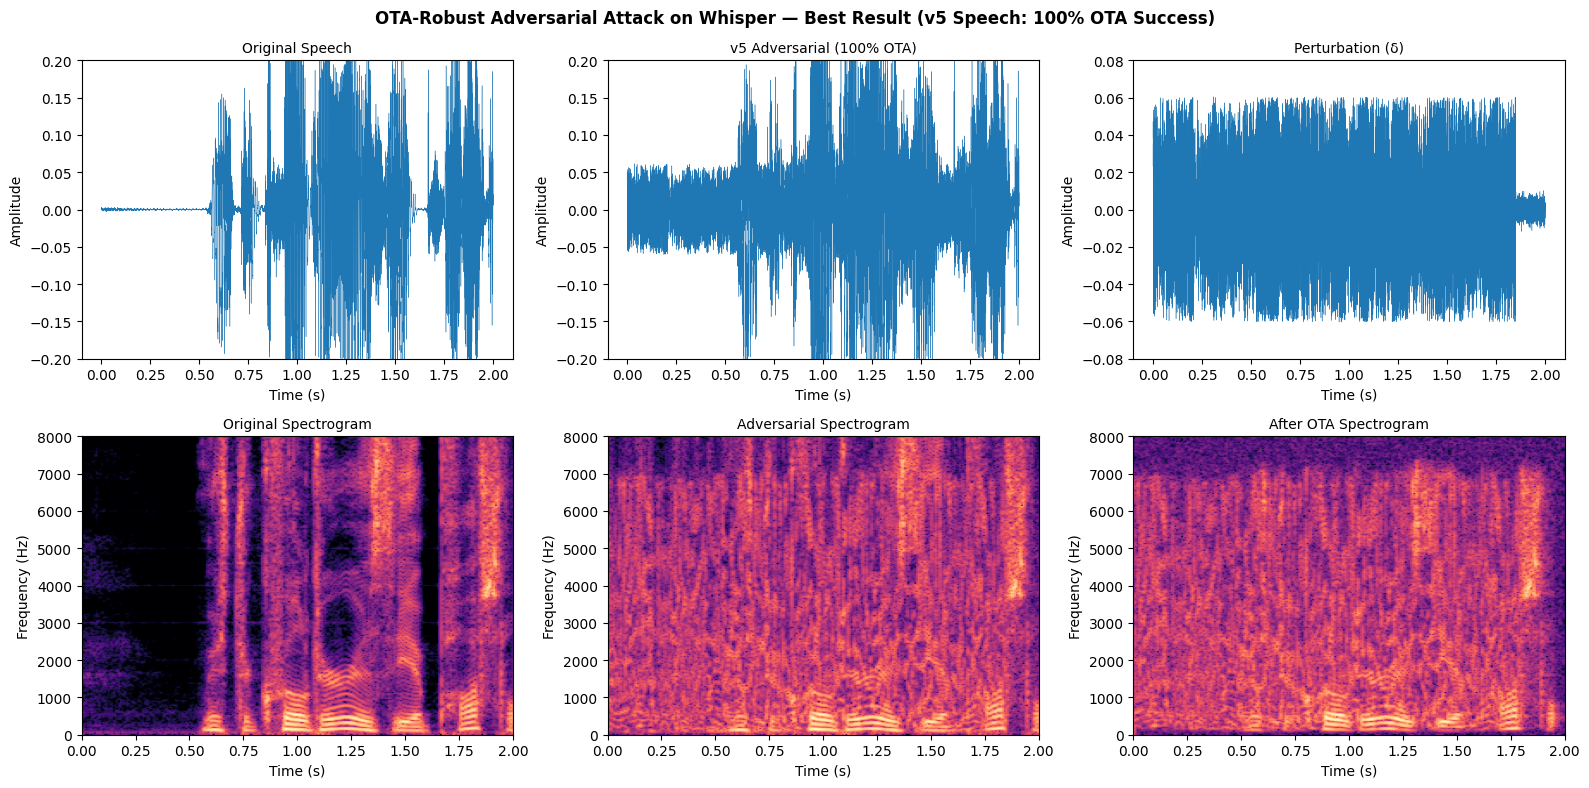


LISTEN: Best OTA-Robust Result

1. Original Speech:


   Transcription: ' Mr. Quilder is the apostle'

2. Adversarial Speech (v5 — target: 'Hello world'):


   After Realistic OTA: ' Hello world'

3. What it sounds like after OTA:



📊 Perturbation Stats: RMS=0.0263 | SNR=8.3 dB | Peak=0.0605


In [45]:
# ============================================================
# Final Visualization: Best Result (v5 Speech — 100% OTA Success)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Load audio
orig_np = original_waveform.cpu().numpy().flatten()
v5_speech, _ = librosa.load("adv_v5_speech.wav", sr=16000)
v5_speech_t = torch.tensor(v5_speech, device=device).float().unsqueeze(0)
ota_v5 = realistic_ota(v5_speech_t.cpu(), sr=16000).numpy().flatten()
delta = v5_speech - orig_np[:len(v5_speech)]

audios = [orig_np, v5_speech, delta, ota_v5]
titles = ["Original Speech", "v5 Adversarial (100% OTA)", "Perturbation (δ)", "After Realistic OTA"]

# Row 1: Waveforms
for i, (audio, title) in enumerate(zip(audios[:3], titles[:3])):
    axes[0, i].plot(np.arange(len(audio)) / 16000, audio, linewidth=0.3)
    axes[0, i].set_title(title, fontsize=10)
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].set_ylabel("Amplitude")
    axes[0, i].set_ylim(-0.2, 0.2) if i < 2 else axes[0, i].set_ylim(-0.08, 0.08)

# Row 2: Spectrograms
spec_audios = [orig_np, v5_speech, ota_v5]
spec_titles = ["Original Spectrogram", "Adversarial Spectrogram", "After OTA Spectrogram"]
for i, (audio, title) in enumerate(zip(spec_audios, spec_titles)):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=512, hop_length=128)), ref=np.max)
    img = axes[1, i].imshow(D, aspect='auto', origin='lower', cmap='magma',
                            extent=[0, len(audio)/16000, 0, 8000])
    axes[1, i].set_title(title, fontsize=10)
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].set_ylabel("Frequency (Hz)")

plt.suptitle("OTA-Robust Adversarial Attack on Whisper — Best Result (v5 Speech: 100% OTA Success)", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Audio players
print("\n" + "=" * 60)
print("LISTEN: Best OTA-Robust Result")
print("=" * 60)

print("\n1. Original Speech:")
display(Audio(data=orig_np, rate=16000, normalize=False))
with torch.no_grad():
    t = processor.batch_decode(
        model.generate(diff_fe(original_waveform).to(model.dtype), forced_decoder_ids=forced_ids),
        skip_special_tokens=True
    )[0]
print(f"   Transcription: '{t}'")

print("\n2. Adversarial Speech (v5 — target: 'Hello world'):")
display(Audio(data=v5_speech, rate=16000, normalize=False))
# Through OTA
ota_t = realistic_ota(v5_speech_t.cpu(), sr=16000).to(device)
with torch.no_grad():
    t_ota = processor.batch_decode(
        model.generate(diff_fe(ota_t).to(model.dtype), forced_decoder_ids=forced_ids),
        skip_special_tokens=True
    )[0]
print(f"   After Realistic OTA: '{t_ota}'")

print("\n3. What it sounds like after OTA:")
display(Audio(data=ota_v5, rate=16000, normalize=False))

# Perturbation only
delta_rms = np.sqrt(np.mean(delta**2))
snr = 20 * np.log10(np.sqrt(np.mean(orig_np**2)) / (delta_rms + 1e-8))
print(f"\n📊 Perturbation Stats: RMS={delta_rms:.4f} | SNR={snr:.1f} dB | Peak={np.abs(delta).max():.4f}")


## v7: Transformation-Based Adversarial Attack (Human-Sounding)

**Key Idea**: Instead of adding perturbation noise (δ) to the original waveform, optimize **audio transformation parameters** that reshape the original speech through standard signal processing operations. The result sounds like naturally transformed speech (pitch-shifted, time-stretched, formant-warped) rather than noise-contaminated audio.

**Transformations (all STFT-domain, fully differentiable)**:
1. **Frequency Warp** — Non-uniform pitch/formant shifting via learnable per-frequency-band shifts  
2. **Spectral Envelope** — Formant emphasis/de-emphasis (smooth per-frequency gains)  
3. **Temporal Envelope** — Rhythm/dynamics modification (smooth per-frame gains)  
4. **Time Stretch** — Tempo change by interpolating STFT along the time axis  
5. **Phase Perturbation** — Subtle timing changes via small phase offsets  

**Why it sounds human**: Only ~97 learnable parameters (control points interpolated to full resolution), so the transforms are inherently smooth. Phase structure from original speech is mostly preserved, maintaining temporal fine-structure that makes audio sound "speech-like".

In [ ]:
# ============================================================
# v7: Transformation-Based Attack (Human-Sounding)
# ============================================================
# Instead of additive perturbation (δ), optimize STFT-domain
# transformation parameters: frequency warp, spectral envelope,
# temporal envelope, time stretch, and phase perturbation.
# All operations are differentiable via smooth control-point
# interpolation (~97 parameters total).
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display


class AudioTransformAttack(nn.Module):
    """
    Differentiable audio transformer that reshapes original speech
    via STFT-domain manipulations with smooth control-point envelopes.
    
    ~97 learnable parameters total:
      - 32 spectral envelope control points (formant shaping)
      - 32 temporal envelope control points (rhythm/dynamics)
      - 16 frequency warp control points (pitch/formant shifting)
      - 16 phase perturbation control points
      - 1 time stretch factor
    """
    
    def __init__(self, n_samples=32000, sr=16000, n_fft=1024, hop_length=256,
                 n_spectral_ctrl=32, n_temporal_ctrl=32, n_freq_warp_ctrl=16,
                 n_phase_ctrl=16, device='cuda'):
        super().__init__()
        self.n_samples = n_samples
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_freqs = n_fft // 2 + 1
        self.device = device
        
        # Control-point parameters (smoothly interpolated to full resolution)
        self.spectral_ctrl = nn.Parameter(torch.zeros(n_spectral_ctrl, device=device))
        self.temporal_ctrl = nn.Parameter(torch.zeros(n_temporal_ctrl, device=device))
        self.freq_warp_ctrl = nn.Parameter(torch.zeros(n_freq_warp_ctrl, device=device))
        self.phase_ctrl = nn.Parameter(torch.zeros(n_phase_ctrl, device=device))
        self.log_time_stretch = nn.Parameter(torch.tensor(0.0, device=device))
    
    def _interp(self, ctrl, target_len):
        """Smooth linear interpolation of control points to target length"""
        return F.interpolate(
            ctrl.view(1, 1, -1), size=target_len,
            mode='linear', align_corners=True
        ).view(-1)
    
    def forward(self, waveform):
        """Apply learned transformations. waveform: (1, N) tensor"""
        x = waveform.squeeze(0)  # (N,)
        window = torch.hann_window(self.n_fft, device=x.device)
        
        # ---- STFT ----
        X = torch.stft(x, n_fft=self.n_fft, hop_length=self.hop_length,
                       win_length=self.n_fft, window=window, return_complex=True)
        n_f, n_t = X.shape
        mag = X.abs() + 1e-8
        phase = X.angle()
        
        # ---- 1. Time Stretch (interpolate STFT along time axis) ----
        stretch = torch.exp(torch.clamp(self.log_time_stretch, -0.22, 0.22))
        new_t = max(2, int(n_t * stretch.item()))
        if abs(stretch.item() - 1.0) > 0.005:
            mag = F.interpolate(mag.unsqueeze(0), size=new_t, mode='linear',
                               align_corners=False).squeeze(0)
            phase = F.interpolate(phase.unsqueeze(0), size=new_t, mode='linear',
                                 align_corners=False).squeeze(0)
            if mag.shape[1] >= n_t:
                mag, phase = mag[:, :n_t], phase[:, :n_t]
            else:
                mag = F.pad(mag, (0, n_t - mag.shape[1]))
                phase = F.pad(phase, (0, n_t - phase.shape[1]))
        
        # ---- 2. Frequency Warp (non-uniform pitch/formant shifting) ----
        warp = self._interp(self.freq_warp_ctrl, n_f)
        warp = torch.tanh(warp) * 40  # max ±40 bins shift per frequency band
        
        freq_idx = torch.arange(n_f, dtype=torch.float32, device=self.device)
        src_idx = torch.clamp(freq_idx - warp, 0, n_f - 1.001)
        
        low = src_idx.floor().long()
        high = (low + 1).clamp(max=n_f - 1)
        frac = (src_idx - low.float()).unsqueeze(1)
        
        mag = mag[low] * (1.0 - frac) + mag[high] * frac
        phase = phase[low] * (1.0 - frac) + phase[high] * frac
        
        # ---- 3. Spectral Envelope (formant emphasis/de-emphasis) ----
        sg = self._interp(self.spectral_ctrl, n_f)
        sg = torch.exp(torch.clamp(sg, -3, 3))  # 0.05x – 20x per-frequency gain
        mag = mag * sg.unsqueeze(1)
        
        # ---- 4. Temporal Envelope (dynamics/rhythm) ----
        tg = self._interp(self.temporal_ctrl, n_t)
        tg = torch.exp(torch.clamp(tg, -2, 2))  # 0.14x – 7.4x per-frame gain
        mag = mag * tg.unsqueeze(0)
        
        # ---- 5. Phase Perturbation ----
        pp = self._interp(self.phase_ctrl, n_f)
        phase = phase + pp.unsqueeze(1) * 0.5  # up to ±0.5 radians
        
        # ---- Reconstruct ----
        X_mod = mag * torch.exp(1j * phase)
        y = torch.istft(X_mod, n_fft=self.n_fft, hop_length=self.hop_length,
                        win_length=self.n_fft, window=window, length=self.n_samples)
        
        return y.unsqueeze(0)  # (1, N)


def run_transform_attack(
    original_audio, target_text, model, processor, diff_fe,
    steps=5000, lr=0.02, similarity_weight=0.05, reg_weight=0.005, device='cuda'
):
    """Optimize audio transformation parameters to make speech transcribe as target."""
    
    manipulator = AudioTransformAttack(
        n_samples=original_audio.shape[-1], sr=16000, device=device
    )
    
    optimizer = torch.optim.Adam(manipulator.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=steps, eta_min=lr * 0.05
    )
    
    target_ids = processor.tokenizer(target_text, return_tensors="pt").input_ids.to(device)
    
    # Reference mel features for similarity loss
    with torch.no_grad():
        ref_feats = diff_fe(original_audio).to(torch.float32)
    
    n_params = sum(p.numel() for p in manipulator.parameters())
    print(f"Transformation Attack | {n_params} learnable params | {steps} steps | lr={lr}")
    print(f"Target: '{target_text}' | sim_weight={similarity_weight} | reg_weight={reg_weight}")
    
    best_ce = float('inf')
    best_state = None
    
    for i in range(steps):
        optimizer.zero_grad()
        
        transformed = manipulator(original_audio)
        
        # CE Loss against target text
        feats = diff_fe(transformed).to(model.dtype)
        outputs = model(input_features=feats, labels=target_ids)
        ce_loss = outputs.loss
        
        # Mel-feature similarity (keeps spectral shape close to original)
        feat_sim = F.mse_loss(feats.float(), ref_feats)
        
        # Parameter regularization (penalize large transforms)
        reg = (
            torch.mean(manipulator.spectral_ctrl ** 2) +
            torch.mean(manipulator.temporal_ctrl ** 2) +
            torch.mean(manipulator.freq_warp_ctrl ** 2) +
            torch.mean(manipulator.phase_ctrl ** 2) +
            manipulator.log_time_stretch ** 2
        )
        
        loss = ce_loss + similarity_weight * feat_sim + reg_weight * reg
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(manipulator.parameters(), max_norm=2.0)
        optimizer.step()
        scheduler.step()
        
        if ce_loss.item() < best_ce:
            best_ce = ce_loss.item()
            best_state = {k: v.clone() for k, v in manipulator.state_dict().items()}
        
        if i % 500 == 0:
            with torch.no_grad():
                stretch = torch.exp(manipulator.log_time_stretch).item()
                warp_max = manipulator.freq_warp_ctrl.abs().max().item()
                spec_max = manipulator.spectral_ctrl.abs().max().item()
                temp_max = manipulator.temporal_ctrl.abs().max().item()
            print(f"  Step {i:5d} | CE: {ce_loss.item():.4f} | Sim: {feat_sim.item():.4f} | "
                  f"Stretch: {stretch:.3f} | Warp: {warp_max:.2f} | "
                  f"Spec: {spec_max:.2f} | Temp: {temp_max:.2f}")
    
    # Load best
    if best_state is not None:
        manipulator.load_state_dict(best_state)
    
    with torch.no_grad():
        best_audio = manipulator(original_audio)
    
    # Summary
    print(f"\nBest CE: {best_ce:.4f}")
    with torch.no_grad():
        s = torch.exp(manipulator.log_time_stretch).item()
        w = torch.tanh(manipulator._interp(manipulator.freq_warp_ctrl, manipulator.n_freqs)) * 40
        print(f"Time stretch: {s:.3f}x")
        print(f"Freq warp range: [{w.min().item():.1f}, {w.max().item():.1f}] bins "
              f"([{w.min().item()*16000/1024:.0f}, {w.max().item()*16000/1024:.0f}] Hz)")
        print(f"Spectral gains (log): [{manipulator.spectral_ctrl.min().item():.2f}, "
              f"{manipulator.spectral_ctrl.max().item():.2f}]")
        print(f"Temporal gains (log): [{manipulator.temporal_ctrl.min().item():.2f}, "
              f"{manipulator.temporal_ctrl.max().item():.2f}]")
        
        corr = np.corrcoef(
            original_audio.cpu().numpy().flatten(),
            best_audio.cpu().numpy().flatten()
        )[0, 1]
        print(f"Waveform correlation with original: {corr:.4f}")
    
    return best_audio, manipulator


# ============================================================
# Run v7 Attack
# ============================================================
print("=" * 60)
print("v7: Transformation-Based Attack (Human-Sounding)")
print("=" * 60)

adv_v7, manip_v7 = run_transform_attack(
    original_audio=original_waveform.clone(),
    target_text="Hello world",
    model=model, processor=processor, diff_fe=diff_fe,
    steps=5000,
    lr=0.02,
    similarity_weight=0.05,
    reg_weight=0.005,
    device=device,
)
sf.write("adv_v7_transform.wav", adv_v7.cpu().numpy().flatten(), 16000)


# ============================================================
# Evaluate
# ============================================================
print("\n" + "=" * 60)
print("v7 EVALUATION")
print("=" * 60)

forced_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")

# Clean transcription
with torch.no_grad():
    t = processor.batch_decode(
        model.generate(diff_fe(adv_v7.to(device)).to(model.dtype), forced_decoder_ids=forced_ids),
        skip_special_tokens=True
    )[0]
print(f"v7 Clean:    '{t}'")

with torch.no_grad():
    t_orig = processor.batch_decode(
        model.generate(diff_fe(original_waveform).to(model.dtype), forced_decoder_ids=forced_ids),
        skip_special_tokens=True
    )[0]
print(f"Original:    '{t_orig}'")

# Realistic OTA
print("\n--- Realistic OTA (10 trials) ---")
succ = 0
for trial in range(10):
    ota = realistic_ota(adv_v7.cpu(), sr=16000).to(device)
    with torch.no_grad():
        t = processor.batch_decode(
            model.generate(diff_fe(ota).to(model.dtype), forced_decoder_ids=forced_ids),
            skip_special_tokens=True
        )[0]
    ok = "hello world" in t.lower()
    if ok: succ += 1
    if trial < 5:
        print(f"  Trial {trial+1}: '{t}' [{'✓' if ok else '✗'}]")
print(f"OTA Success: {succ}/10 ({succ*10}%)")


# ============================================================
# Visualization
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("v7: Transformation-Based Attack", fontsize=14)

orig_np = original_waveform.cpu().numpy().flatten()
adv_np = adv_v7.cpu().numpy().flatten()

# Waveforms
axes[0, 0].plot(orig_np, alpha=0.7, linewidth=0.5)
axes[0, 0].set_title("Original Waveform")
axes[0, 0].set_ylim(-0.5, 0.5)

axes[0, 1].plot(adv_np, alpha=0.7, linewidth=0.5, color='orange')
axes[0, 1].set_title("Transformed Waveform (v7)")
axes[0, 1].set_ylim(-0.5, 0.5)

axes[0, 2].plot(adv_np - orig_np, alpha=0.7, linewidth=0.5, color='red')
axes[0, 2].set_title("Difference (transform effect)")

# Spectrograms
S_orig = librosa.feature.melspectrogram(y=orig_np, sr=16000, n_mels=80)
S_adv = librosa.feature.melspectrogram(y=adv_np, sr=16000, n_mels=80)

librosa.display.specshow(librosa.power_to_db(S_orig, ref=np.max),
                         sr=16000, ax=axes[1, 0], cmap='magma')
axes[1, 0].set_title("Original Mel Spectrogram")

librosa.display.specshow(librosa.power_to_db(S_adv, ref=np.max),
                         sr=16000, ax=axes[1, 1], cmap='magma')
axes[1, 1].set_title("Transformed Mel Spectrogram")

librosa.display.specshow(librosa.power_to_db(np.abs(S_adv - S_orig) + 1e-8, ref=np.max),
                         sr=16000, ax=axes[1, 2], cmap='hot')
axes[1, 2].set_title("Spectrogram Difference")

plt.tight_layout()
plt.show()

# Transformation parameters visualization
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8))
fig2.suptitle("v7: Learned Transformation Parameters", fontsize=14)

with torch.no_grad():
    sg = manip_v7.spectral_ctrl.cpu().numpy()
    tg = manip_v7.temporal_ctrl.cpu().numpy()
    warp = manip_v7.freq_warp_ctrl.cpu().numpy()
    ph = manip_v7.phase_ctrl.cpu().numpy()

axes2[0, 0].bar(range(len(sg)), sg, color='steelblue')
axes2[0, 0].set_title("Spectral Envelope (log gains)")
axes2[0, 0].set_xlabel("Control point")

axes2[0, 1].bar(range(len(tg)), tg, color='coral')
axes2[0, 1].set_title("Temporal Envelope (log gains)")
axes2[0, 1].set_xlabel("Control point")

axes2[1, 0].bar(range(len(warp)), np.tanh(warp) * 40, color='forestgreen')
axes2[1, 0].set_title("Frequency Warp (bins shift)")
axes2[1, 0].set_xlabel("Control point")

axes2[1, 1].bar(range(len(ph)), ph, color='purple')
axes2[1, 1].set_title("Phase Perturbation")
axes2[1, 1].set_xlabel("Control point")

plt.tight_layout()
plt.show()

# Audio players
print("\n--- Listen ---")
print("Original speech:")
display(Audio(data=orig_np, rate=16000, normalize=False))
print("v7 Transformed (should still sound like speech):")
display(Audio(data=adv_np, rate=16000, normalize=False))

v7: Transformation-Based Attack (Human-Sounding)
Transformation Attack | 97 learnable params | 5000 steps | lr=0.02
Target: 'Hello world' | sim_weight=0.05 | reg_weight=0.005
  Step     0 | CE: 8.7109 | Sim: 0.0000 | Stretch: 1.000 | Warp: 0.02 | Spec: 0.02 | Temp: 0.02
  Step   500 | CE: 6.6758 | Sim: 0.0170 | Stretch: 1.000 | Warp: 0.53 | Spec: 2.13 | Temp: 2.70
  Step  1000 | CE: 6.4219 | Sim: 0.0566 | Stretch: 1.000 | Warp: 0.54 | Spec: 3.20 | Temp: 3.23
  Step  1500 | CE: 5.9453 | Sim: 0.0388 | Stretch: 1.000 | Warp: 0.82 | Spec: 3.45 | Temp: 3.31
